# 02 — PostgreSQL Pipeline

**Người thực hiện:** Cao Tấn Phát - Database

## 1. Mục tiêu của Notebook, vai trò của PostgreSQL trong dự án và kiến trúc pipeline

### 1.1. Mục tiêu của Notebook


Notebook này xây dựng nền tảng dữ liệu cho toàn bộ dự án bằng PostgreSQL, dựa trên năm bộ dữ liệu có cấp quan sát khác nhau: **Global, Country, State, City** và **Major City**. Các mục tiêu cụ thể gồm:

1. Import đầy đủ năm file CSV vào PostgreSQL và bảo toàn dữ liệu nguồn trong staging layer.
2. Kiểm tra row count, kiểu dữ liệu, primary key và duplicate sau import.
3. Chuẩn hóa dữ liệu thành các bảng dimension và fact có quan hệ rõ ràng.
4. Thực hiện join đúng grain, kiểm tra mất dữ liệu và ngăn row multiplication.
5. Tạo monthly analytical views, materialized views và indexes phục vụ các bước phân tích tiếp theo.
6. Hoàn thành final audit và bàn giao nguồn dữ liệu nhất quán cho Notebook 03.

### 1.2. Vai trò của PostgreSQL trong dự án

PostgreSQL không chỉ là nơi lưu trữ CSV sau import mà còn là **nền tảng quản lý và xử lý dữ liệu trung tâm** của dự án. PostgreSQL đảm nhận các vai trò sau:

- **Lưu trữ tập trung:** quản lý năm bộ dữ liệu trong cùng một database, thay vì để các notebook đọc rời rạc từ nhiều file CSV.
- **Bảo đảm tính toàn vẹn:** sử dụng data type, primary key, foreign key, UNIQUE và CHECK constraints để kiểm soát cấu trúc và quan hệ dữ liệu.
- **Tích hợp dữ liệu:** thực hiện chuẩn hóa, join và aggregation trực tiếp bằng SQL, đồng thời kiểm tra unmatched rows và row multiplication.
- **Tối ưu truy vấn:** sử dụng indexes, views và materialized views để hỗ trợ truy vấn trên dữ liệu City có hơn năm triệu dòng.
- **Bảo toàn khả năng truy vết:** cột `source_staging_id` trong các fact tables cho phép đối chiếu bản ghi phân tích với dòng staging ban đầu.
- **Tạo nguồn dữ liệu thống nhất:** Notebook 03 và các notebook sau đọc dữ liệu từ PostgreSQL thay vì quay lại CSV, giúp pipeline nhất quán và gần với quy trình triển khai thực tế.
- **Hỗ trợ tái lập và bàn giao:** database có thể được backup, restore và kiểm tra lại trên máy của các thành viên khác trong nhóm.

### 1.3. Kiến trúc pipeline

```text
5 CSV gốc
   ↓ PostgreSQL COPY
Staging layer
   ↓ chuẩn hóa khóa, địa điểm và tọa độ
Dimension + Fact layer
   ↓
Monthly analytical views
   ↓
Join validation + Aggregation + Index
   ↓
Final audit
   ↓
Monthly views bàn giao cho Notebook 03
```

Các nguyên tắc thiết kế chính:

- Staging giữ dữ liệu gần với CSV và không thực hiện data cleaning.
- Không join trực tiếp các bảng khác grain để tạo một bảng lớn gây row explosion.
- Mỗi fact giữ `source_staging_id` để duy trì data lineage.
- Monthly views là data contract chính được bàn giao cho Notebook 03.


## 2. Chuẩn bị môi trường Python, cài đặt thư viện và kết nối PostgreSQL

Mục 2 sử dụng Python để chuẩn bị môi trường và kiểm tra khả năng kết nối PostgreSQ

### 2.1. Cài đặt thư viện Python

Các thư viện được sử dụng gồm:

- `pandas`: hỗ trợ đọc kết quả truy vấn trong các notebook tiếp theo.
- `psycopg2-binary`: PostgreSQL driver dùng để kiểm tra kết nối trực tiếp.
- `SQLAlchemy`: tạo database engine chuẩn hóa cho `pd.read_sql()` và các notebook sau.

### 2.2. Kết nối Database

Trong mục này, Python được dùng để thiết lập kết nối tới PostgreSQL đang chạy cục bộ. Kết nối ban đầu sử dụng database bảo trì `postgres`, vì database phân tích `climate_db` sẽ được tạo và xác nhận ở Mục 3.

Các hằng số `DB_HOST`, `DB_PORT`, `DB_NAME`, `DB_USER` và `DB_PASSWORD` chứa thông tin kết nối trên máy đang chạy notebook. Người thực hiện cần thay đổi các giá trị này nếu cấu hình PostgreSQL cục bộ khác với ví dụ. `connection_config` được dùng cho `psycopg2`, còn `URL.create()` tạo URL kết nối cho SQLAlchemy và xử lý an toàn các ký tự đặc biệt trong mật khẩu.

Cell code tạo hai đối tượng để sử dụng trong Mục 2.3: kết nối trực tiếp `pg_connection` của `psycopg2` và `engine` của SQLAlchemy.

In [2]:
# Nhập các thư viện cần thiết để kết nối PostgreSQL bằng Python.
import pandas as pd
import psycopg2
from sqlalchemy import URL, create_engine

# Cấu hình PostgreSQL cục bộ; thay đổi nếu máy sử dụng host, port hoặc user khác.
DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'postgres'  # Database bảo trì có sẵn sau khi cài PostgreSQL.
DB_USER = 'postgres'
DB_PASSWORD = '123'
connection_config = {
    'host': DB_HOST,
    'port': DB_PORT,
    'dbname': DB_NAME,
    'user': DB_USER,
    'password': DB_PASSWORD,
    'connect_timeout': 10,
}

try:
    # psycopg2 mở kết nối trực tiếp để thực thi và kiểm tra câu lệnh SQL.
    pg_connection = psycopg2.connect(**connection_config)

    # URL.create xử lý ký tự đặc biệt trong mật khẩu an toàn hơn việc ghép chuỗi.
    sqlalchemy_url = URL.create(
        drivername='postgresql+psycopg2',
        username=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        port=DB_PORT,
        database=DB_NAME,
    )
    engine = create_engine(sqlalchemy_url, pool_pre_ping=True)
except psycopg2.Error as error:
    raise ConnectionError(
        'Không thể kết nối PostgreSQL. Hãy kiểm tra service, host, port, user và mật khẩu.'
    ) from error

print(f'Đã mở kết nối psycopg2 tới {DB_HOST}:{DB_PORT}/{DB_NAME}.')
print('Đã khởi tạo SQLAlchemy engine để kết nối PostgreSQL.')

Đã mở kết nối psycopg2 tới localhost:5432/postgres.
Đã khởi tạo SQLAlchemy engine để kết nối PostgreSQL.


Khi cell chạy thành công, dòng output đầu tiên xác nhận `psycopg2` đã mở kết nối tới database bảo trì `postgres`. Điều đó cho thấy PostgreSQL server đang hoạt động và chấp nhận host, port, user cùng mật khẩu đã khai báo. Dòng output thứ hai chỉ xác nhận SQLAlchemy engine đã được khởi tạo; engine chưa mở kết nối thật cho đến khi truy vấn `SELECT 1` được thực hiện trong Mục 2.3.

Nếu xuất hiện `ConnectionError`, chưa nên tiếp tục pipeline. Cần kiểm tra PostgreSQL service, host, port, user và mật khẩu trong cell cấu hình.

### 2.3. Kiểm tra kết nối PostgreSQL bằng Python


Mục này kiểm tra hai cơ chế kết nối đã tạo ở Mục 2.2 bằng các truy vấn chỉ đọc. Với `psycopg2`, truy vấn trả về database hiện tại, user hiện tại và phiên bản PostgreSQL. Với SQLAlchemy, `SELECT 1` được dùng làm phép kiểm tra kết nối tối thiểu.

Kết quả được trình bày thành bảng để người chạy dễ đối chiếu. Dù truy vấn thành công hay phát sinh lỗi, kết nối và engine đều được đóng ở cuối cell để giải phóng tài nguyên.

In [3]:
# text được nhập tại đây vì chỉ Mục 2.3 cần thực thi SQL qua SQLAlchemy.
from sqlalchemy import text

try:
    # Xác minh database, user và phiên bản server bằng psycopg2.
    with pg_connection.cursor() as cursor:
        cursor.execute(
            'SELECT current_database(), current_user, version();'
        )
        current_database, current_user, server_version = cursor.fetchone()

    # Buộc SQLAlchemy engine mở kết nối thật và thực thi truy vấn tối thiểu.
    with engine.connect() as sqlalchemy_connection:
        sqlalchemy_check = sqlalchemy_connection.execute(
            text('SELECT 1;')
        ).scalar_one()

    if sqlalchemy_check != 1:
        raise RuntimeError('SQLAlchemy không trả về kết quả kiểm tra mong đợi.')

    # Tổng hợp kết quả để hiển thị rõ ràng trong notebook.
    connection_validation_df = pd.DataFrame([
        {'check': 'Database hiện tại', 'value': current_database},
        {'check': 'User hiện tại', 'value': current_user},
        {'check': 'PostgreSQL server', 'value': server_version.splitlines()[0]},
        {'check': 'SQLAlchemy SELECT 1', 'value': sqlalchemy_check},
    ])
    display(connection_validation_df)
    print('PASS: Cả psycopg2 và SQLAlchemy đều kết nối PostgreSQL thành công.')
finally:
    # Luôn đóng tài nguyên kết nối sau khi hoàn thành kiểm tra.
    if 'pg_connection' in globals() and not pg_connection.closed:
        pg_connection.close()
    if 'engine' in globals():
        engine.dispose()

,check,value
0,Database hiện tại,postgres
1,User hiện tại,postgres
2,PostgreSQL server,"PostgreSQL 18.3 on x86_64-windows, compiled by..."
3,SQLAlchemy SELECT 1,1


PASS: Cả psycopg2 và SQLAlchemy đều kết nối PostgreSQL thành công.


Kết nối đạt yêu cầu khi bảng kết quả hiển thị database hiện tại là `postgres`, user đúng với `DB_USER`, thông tin phiên bản PostgreSQL và giá trị `SQLAlchemy SELECT 1` bằng `1`. Dòng trạng thái `PASS` xác nhận cả hai cơ chế kết nối đều hoạt động.

Database `postgres` ở đây chỉ được dùng để xác nhận server và làm database bảo trì. Database phân tích `climate_db` sẽ được tạo hoặc xác nhận trong Mục 3 trước khi chạy các bước tạo bảng, import, join và aggregation. Sau cell kiểm tra, các kết nối đã được đóng nên không giữ tài nguyên PostgreSQL ngoài ý muốn.

## 3. Tạo database

Cell SQL đầu tiên tạo database phân tích `climate_db`, là nơi lưu trữ toàn bộ staging tables, dimension tables, fact tables, views và kết quả aggregation của dự án.

Trong pgAdmin 4, cần mở **Query Tool của database `postgres`** rồi chạy riêng lệnh bên dưới.

In [ ]:
CREATE DATABASE climate_db;

## 4. Xác nhận data contract trước import

Notebook 01 đã xác nhận năm CSV có cấu trúc hợp lệ.

Row count:

- Global: 3,192
- Country: 577,462
- State: 645,675
- City: 8,599,212
- Major City: 239,177

## 5. Tạo staging tables

Staging dùng kiểu dữ liệu PostgreSQL phù hợp; nhiệt độ có thể NULL vì dữ liệu lịch sử có missing values. Các cột tọa độ tạm giữ dạng TEXT để bảo toàn định dạng N/S/E/W trước bước chuẩn hóa.

### 5.1. Tạo bảng `staging_global`

In [ ]:
CREATE TABLE staging_global (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    land_average_temperature DOUBLE PRECISION,
    land_average_temperature_uncertainty DOUBLE PRECISION,
    land_max_temperature DOUBLE PRECISION,
    land_max_temperature_uncertainty DOUBLE PRECISION,
    land_min_temperature DOUBLE PRECISION,
    land_min_temperature_uncertainty DOUBLE PRECISION,
    land_and_ocean_average_temperature DOUBLE PRECISION,
    land_and_ocean_average_temperature_uncertainty DOUBLE PRECISION,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_global IS
    'Raw monthly global data from GlobalTemperatures.csv';

Bảng `staging_global` lưu dữ liệu theo grain **một quan sát toàn cầu tại một tháng**, tương ứng với `GlobalTemperatures.csv`. `staging_id` là khóa chính tự tăng dùng để định danh và truy vết từng dòng sau khi import; `dt` lưu thời điểm quan sát dưới dạng `DATE`.

Các giá trị nhiệt độ trung bình, cao nhất, thấp nhất, nhiệt độ đất liền và đại dương cùng độ bất định được lưu bằng `DOUBLE PRECISION`. Các cột nhiệt độ không đặt `NOT NULL` vì dữ liệu lịch sử có missing values. `loaded_at` tự ghi thời điểm dữ liệu được nạp, còn `COMMENT ON TABLE` lưu mô tả nguồn dữ liệu ngay trong PostgreSQL. Sau khi chạy thành công, bảng mới chỉ có cấu trúc và chưa chứa bản ghi; dữ liệu sẽ được import ở Mục 6.

#### Giải thích kiểu dữ liệu DOUBLE PRECISION

`DOUBLE PRECISION` là kiểu số thực dấu phẩy động 64-bit của PostgreSQL. Mỗi giá trị chiếm 8 byte và cung cấp độ chính xác xấp xỉ 15 chữ số có nghĩa. Kiểu dữ liệu này lưu được số thập phân và số âm nên phù hợp với nhiệt độ, độ bất định của phép đo và các phép tính thống kê như `AVG`, `MIN`, `MAX` hoặc độ lệch chuẩn.

Trong bộ dữ liệu của dự án, nhiệt độ thường chỉ có một vài chữ số sau dấu thập phân. Vì vậy, `DOUBLE PRECISION` cung cấp độ chính xác đủ lớn, đồng thời tính toán nhanh và sử dụng ít tài nguyên hơn kiểu số chính xác tuyệt đối `NUMERIC`. So với `REAL` 32-bit, `DOUBLE PRECISION` có độ chính xác cao hơn và phù hợp hơn với dữ liệu khoa học được tổng hợp qua hàng triệu bản ghi.

| Kiểu dữ liệu | Dung lượng | Đặc điểm |
|---|---:|---|
| `REAL` | 4 byte | Số thực gần đúng, độ chính xác khoảng 6 chữ số |
| `DOUBLE PRECISION` | 8 byte | Số thực gần đúng, độ chính xác khoảng 15 chữ số |
| `NUMERIC` | Thay đổi | Số thập phân chính xác, phù hợp với dữ liệu như tiền tệ nhưng tốn chi phí xử lý hơn |

Do được biểu diễn theo hệ nhị phân, `DOUBLE PRECISION` có thể xuất hiện sai số rất nhỏ trong một số phép tính thập phân. Khi trình bày báo cáo, có thể ép kết quả sang `NUMERIC` rồi làm tròn, chẳng hạn `ROUND(AVG(average_temperature)::NUMERIC, 2)`. Không nên kiểm tra hai giá trị `DOUBLE PRECISION` bằng phép bằng tuyệt đối nếu chúng là kết quả của nhiều phép tính; nên so sánh theo một khoảng sai số phù hợp.

Kiểu dữ liệu này không tự chuyển ô trống thành missing value. Trong Mục 6, tùy chọn `NULL ''` của lệnh `COPY` mới đảm nhận việc chuyển trường CSV rỗng thành `NULL`. Vì các cột nhiệt độ ở staging tables không có ràng buộc `NOT NULL`, PostgreSQL có thể bảo toàn các missing values từ dữ liệu lịch sử để Notebook 03 xử lý sau.

### 5.2. Tạo bảng `staging_country`

In [ ]:
CREATE TABLE staging_country (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    country TEXT,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_country IS
    'Raw monthly country data from GlobalLandTemperaturesByCountry.csv';

Bảng `staging_country` lưu dữ liệu theo grain **một quốc gia tại một tháng**, tương ứng với `GlobalLandTemperaturesByCountry.csv`. Ngoài `staging_id`, `dt` và `loaded_at`, bảng giữ nguyên ba trường chính từ CSV: nhiệt độ trung bình, độ bất định và tên quốc gia.

`country` được lưu dưới dạng `TEXT` để bảo toàn tên địa lý như dữ liệu nguồn. Ở staging layer chưa chuẩn hóa tên quốc gia, chưa loại bỏ missing values và chưa đặt ràng buộc duy nhất theo quốc gia–tháng; các công việc làm sạch thuộc Notebook 03. Khi lệnh hoàn tất, PostgreSQL tạo bảng và gắn mô tả nguồn bằng `COMMENT ON TABLE`.

### 5.3. Tạo bảng `staging_state`

In [ ]:
CREATE TABLE staging_state (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    state TEXT,
    country TEXT,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_state IS
    'Raw monthly state data from GlobalLandTemperaturesByState.csv';

Bảng `staging_state` lưu dữ liệu theo grain **một bang hoặc tỉnh thuộc một quốc gia tại một tháng**, tương ứng với `GlobalLandTemperaturesByState.csv`. Hai cột `state` và `country` phải được giữ cùng nhau vì tên bang/tỉnh có thể không đủ để xác định duy nhất một địa điểm giữa các quốc gia.

Nhiệt độ và độ bất định tiếp tục dùng `DOUBLE PRECISION` và được phép nhận `NULL` để phản ánh đúng dữ liệu lịch sử. Bảng staging chỉ tiếp nhận dữ liệu gần với CSV gốc; việc chuẩn hóa khóa địa lý và xử lý chất lượng dữ liệu sẽ được thực hiện ở lớp xử lý sau.

### 5.4. Tạo bảng `staging_city`

In [ ]:
CREATE TABLE staging_city (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    city TEXT,
    country TEXT,
    latitude TEXT,
    longitude TEXT,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_city IS
    'Raw monthly city data from GlobalLandTemperaturesByCity.csv';

Bảng `staging_city` lưu dữ liệu theo grain **một thành phố–quốc gia–tọa độ tại một tháng**, tương ứng với `GlobalLandTemperaturesByCity.csv`. Không nên dùng riêng tên `city` làm khóa địa lý vì nhiều thành phố có thể trùng tên; `country`, `latitude` và `longitude` cung cấp thêm ngữ cảnh để nhận diện địa điểm.

Hai cột tọa độ tạm thời dùng `TEXT` nhằm giữ nguyên ký hiệu hướng như `N`, `S`, `E`, `W` trong CSV và tránh làm thay đổi dữ liệu khi import. Việc chuyển chúng thành tọa độ số thuộc bước chuẩn hóa sau. Đây là bảng có dung lượng lớn nhất nên việc import và kiểm tra row count ở Mục 6 có thể mất nhiều thời gian hơn các bảng còn lại.

### 5.5. Tạo bảng `staging_major_city`

In [ ]:
CREATE TABLE staging_major_city (
    staging_id BIGSERIAL PRIMARY KEY,
    dt DATE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    city TEXT,
    country TEXT,
    latitude TEXT,
    longitude TEXT,
    loaded_at TIMESTAMPTZ NOT NULL DEFAULT CURRENT_TIMESTAMP
);

COMMENT ON TABLE staging_major_city IS
    'Raw monthly major-city data from GlobalLandTemperaturesByMajorCity.csv';

Bảng `staging_major_city` lưu dữ liệu theo grain **một thành phố lớn–quốc gia–tọa độ tại một tháng**, tương ứng với `GlobalLandTemperaturesByMajorCity.csv`. Cấu trúc của bảng gần giống `staging_city`, nhưng hai nguồn được giữ riêng để bảo toàn phạm vi và khả năng truy vết của từng dataset.

Tên địa điểm và tọa độ vẫn được giữ nguyên như CSV; các cột nhiệt độ được phép `NULL`. Lệnh `COMMIT` ở cuối xác nhận transaction nếu pgAdmin đang tắt Auto-commit hoặc các lệnh tạo bảng được chạy trong transaction thủ công. Nếu Auto-commit đang bật, pgAdmin có thể thông báo không có transaction đang mở; cảnh báo này không làm thay đổi cấu trúc bảng đã tạo.

### 5.6. Kiểm tra các staging tables sau khi tạo

In [ ]:
-- Phải trả về đúng 5 bảng, mỗi bảng có row_count = 0.
SELECT 'staging_global' AS table_name, COUNT(*) AS row_count
FROM staging_global
UNION ALL
SELECT 'staging_country', COUNT(*) FROM staging_country
UNION ALL
SELECT 'staging_state', COUNT(*) FROM staging_state
UNION ALL
SELECT 'staging_city', COUNT(*) FROM staging_city
UNION ALL
SELECT 'staging_major_city', COUNT(*) FROM staging_major_city
ORDER BY table_name;


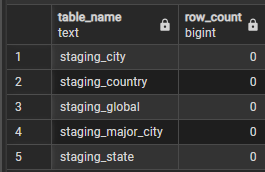

Kết quả truy vấn hiển thị năm dòng tương ứng với `staging_global`, `staging_country`, `staging_state`, `staging_city` và `staging_major_city`. Việc truy vấn thực hiện thành công trên cả năm bảng chứng minh các staging tables đã được tạo và có thể được truy cập trong database hiện tại.

Tất cả giá trị `row_count` đều bằng `0`, đúng với trạng thái mong đợi ngay sau khi tạo bảng và trước khi import CSV.

Phép kiểm tra này mới xác nhận sự tồn tại và số lượng bản ghi của các bảng, chưa xác minh chi tiết tên cột, kiểu dữ liệu hoặc constraint. Những nội dung đó được xác định bởi các câu lệnh `CREATE TABLE` ở Mục 5.1–5.5, còn tính đầy đủ của dữ liệu sẽ được đánh giá lại bằng row count và các truy vấn validation sau khi import.

## 6. Import 5 CSV vào staging bằng COPY

Mục này sử dụng lệnh `COPY` của PostgreSQL để nạp lần lượt năm file CSV vào các staging tables đã tạo ở Mục 5. Các lệnh cần được chạy trong **Query Tool của database `climate_db`**, sau khi Mục 5.6 xác nhận cả năm bảng đang rỗng.

Danh sách cột được khai báo rõ trong từng lệnh để khớp đúng thứ tự cột của CSV. Hai cột do PostgreSQL quản lý không xuất hiện trong danh sách import: `staging_id` tự tăng bằng sequence và `loaded_at` nhận thời điểm nạp từ giá trị mặc định. Các tùy chọn chung có ý nghĩa như sau:

- `FORMAT CSV`: đọc dữ liệu theo định dạng CSV.
- `HEADER TRUE`: bỏ qua dòng tiêu đề đầu tiên.
- `DELIMITER ','`: dùng dấu phẩy để phân tách các trường.
- `QUOTE` và `ESCAPE` bằng dấu nháy kép: đọc đúng chuỗi có dấu phẩy hoặc dấu nháy bên trong.
- `NULL ''`: chuyển trường trống thành giá trị SQL `NULL`.
- `ENCODING 'UTF8'`: đọc file bằng mã hóa UTF-8.

### 6.1. Import `GlobalTemperatures.csv` vào `staging_global`

In [ ]:
COPY staging_global (
    dt,
    land_average_temperature,
    land_average_temperature_uncertainty,
    land_max_temperature,
    land_max_temperature_uncertainty,
    land_min_temperature,
    land_min_temperature_uncertainty,
    land_and_ocean_average_temperature,
    land_and_ocean_average_temperature_uncertainty
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalTemperatures.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh `COPY` ánh xạ chín cột của `GlobalTemperatures.csv` vào các cột ngày, nhiệt độ và độ bất định của `staging_global`. PostgreSQL tự sinh `staging_id` và tự gán `loaded_at` cho mỗi bản ghi.

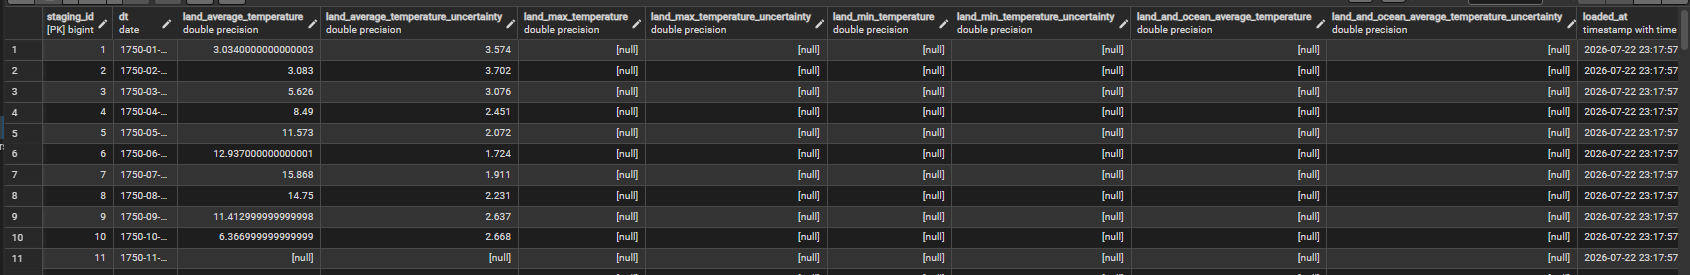

### 6.2. Import `GlobalLandTemperaturesByCountry.csv` vào `staging_country`

In [ ]:
COPY staging_country (
    dt,
    average_temperature,
    average_temperature_uncertainty,
    country
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalLandTemperaturesByCountry.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh này nạp ngày quan sát, nhiệt độ trung bình, độ bất định và tên quốc gia từ `GlobalLandTemperaturesByCountry.csv` vào `staging_country`. Dữ liệu tên quốc gia được giữ nguyên như nguồn, chưa chuẩn hóa hoặc làm sạch ở staging layer.

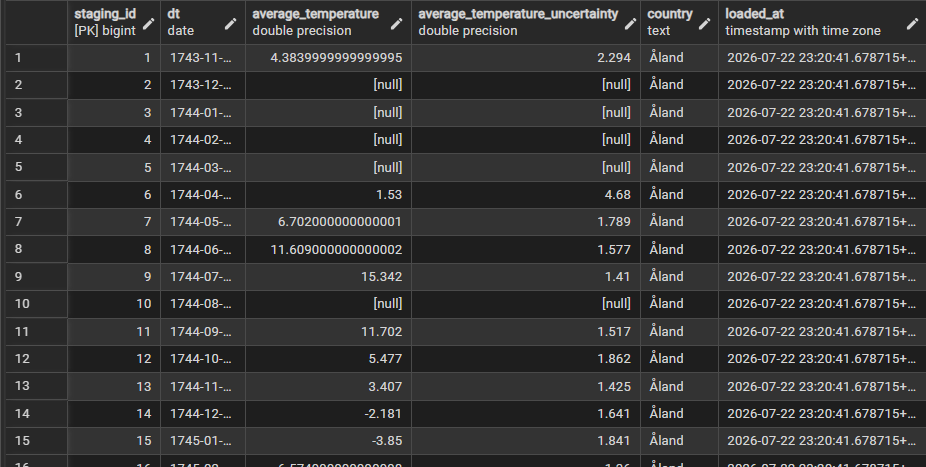

### 6.3. Import `GlobalLandTemperaturesByState.csv` vào `staging_state`

In [ ]:
COPY staging_state (
    dt,
    average_temperature,
    average_temperature_uncertainty,
    state,
    country
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalLandTemperaturesByState.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh `COPY` nạp năm trường của `GlobalLandTemperaturesByState.csv` vào `staging_state`, trong đó `state` luôn đi cùng `country` để bảo toàn đầy đủ ngữ cảnh địa lý của mỗi quan sát. Các trường nhiệt độ trống trong CSV được chuyển thành `NULL`.

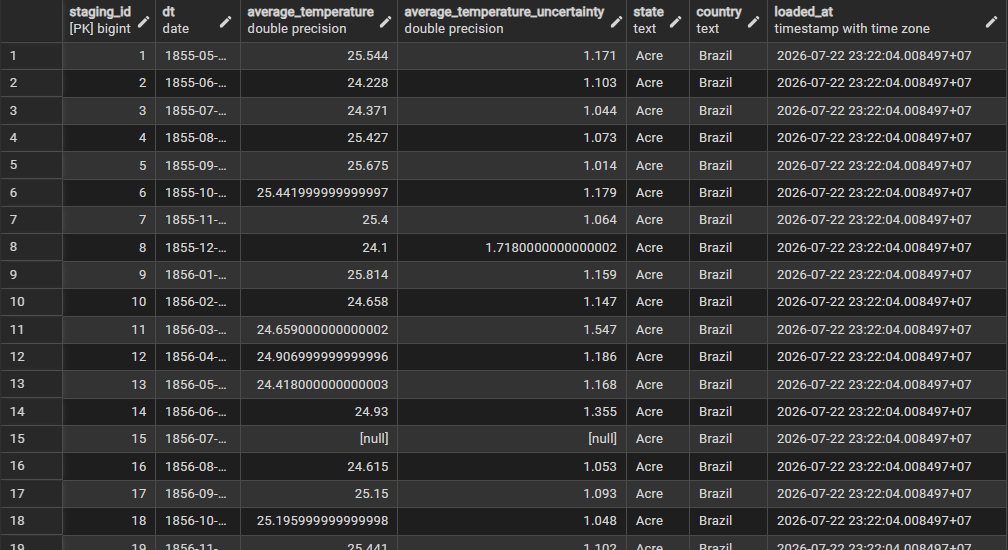

### 6.4. Import `GlobalLandTemperaturesByCity.csv` vào `staging_city`

In [ ]:
COPY staging_city (
    dt,
    average_temperature,
    average_temperature_uncertainty,
    city,
    country,
    latitude,
    longitude
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalLandTemperaturesByCity.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh này nạp dữ liệu thành phố gồm ngày, nhiệt độ, độ bất định, tên thành phố, quốc gia, vĩ độ và kinh độ vào `staging_city`. Tọa độ được nhập dưới dạng `TEXT` để giữ nguyên các ký hiệu hướng `N`, `S`, `E`, `W`; việc chuyển thành số có dấu được thực hiện ở analytical layer.

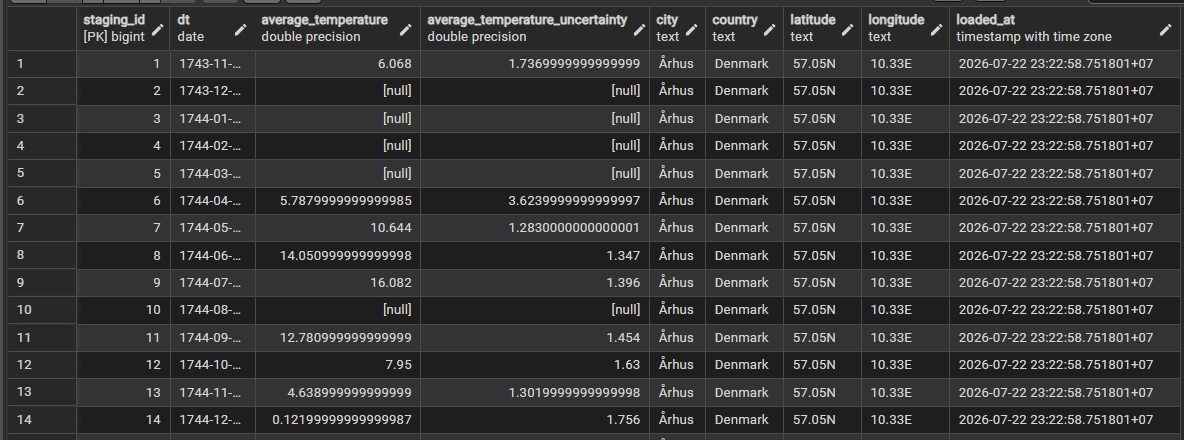

### 6.5. Import `GlobalLandTemperaturesByMajorCity.csv` vào `staging_major_city`

In [ ]:
COPY staging_major_city (
    dt,
    average_temperature,
    average_temperature_uncertainty,
    city,
    country,
    latitude,
    longitude
)
FROM 'E:/FPT/HocKy3/PROJECT_1/PROJECT/Global-Surface-Temperature-Analysis/data/raw/GlobalLandTemperaturesByMajorCity.csv'
WITH (
    FORMAT CSV,
    HEADER TRUE,
    DELIMITER ',',
    QUOTE '"',
    ESCAPE '"',
    NULL '',
    ENCODING 'UTF8'
);

Lệnh `COPY` cuối cùng nạp dữ liệu của các thành phố lớn vào `staging_major_city`. Mặc dù có cấu trúc gần giống dữ liệu City, dataset này được lưu trong bảng riêng để giữ đúng phạm vi nguồn và hỗ trợ truy vết độc lập.

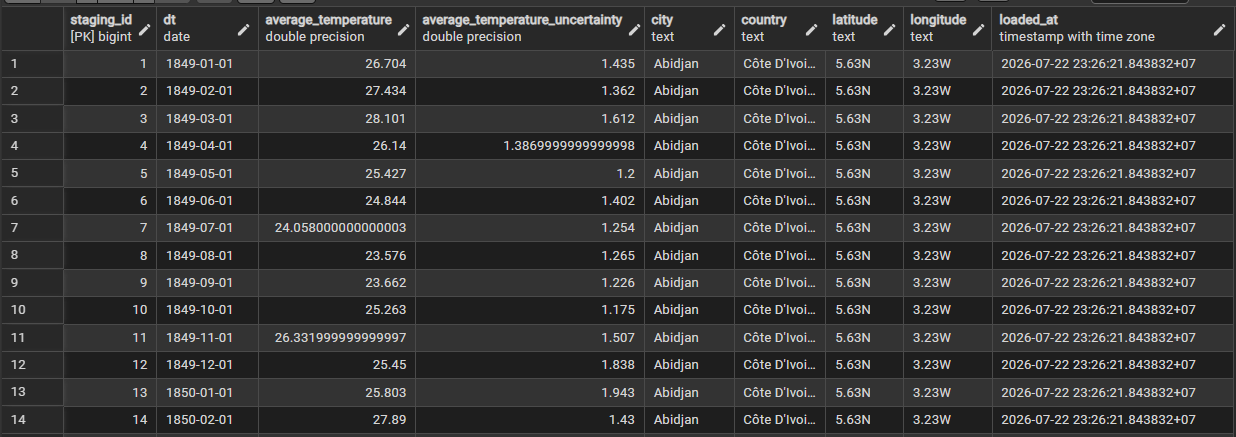

## 7. Kiểm tra dữ liệu sau import

Mục này kiểm tra dữ liệu ngay sau khi năm CSV nguyên bản được import vào staging layer và **trước khi thực hiện cắt dữ liệu ở Mục 8**. Ba nhóm kiểm tra lần lượt đối chiếu số dòng, xác nhận schema/primary key và phát hiện duplicate theo grain nghiệp vụ.

### 7.1. Đối chiếu số dòng và metadata nạp dữ liệu

In [ ]:
WITH expected(dataset, expected_rows) AS (
    VALUES
        ('global', 3192::BIGINT),
        ('country', 577462::BIGINT),
        ('state', 645675::BIGINT),
        ('city', 8599212::BIGINT), -- Dữ liệu City nguyên bản, trước khi cắt ở Mục 8.
        ('major_city', 239177::BIGINT)
),
actual(dataset, actual_rows, min_staging_id, max_staging_id, null_loaded_at) AS (
    SELECT
        'global',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_global
    UNION ALL
    SELECT
        'country',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_country
    UNION ALL
    SELECT
        'state',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_state
    UNION ALL
    SELECT
        'city',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_city
    UNION ALL
    SELECT
        'major_city',
        COUNT(*),
        MIN(staging_id),
        MAX(staging_id),
        COUNT(*) FILTER (WHERE loaded_at IS NULL)
    FROM staging_major_city
)
SELECT
    e.dataset,
    e.expected_rows,
    a.actual_rows,
    a.actual_rows - e.expected_rows AS difference,
    a.min_staging_id,
    a.max_staging_id,
    a.null_loaded_at,
    CASE
        WHEN a.actual_rows = e.expected_rows
         AND a.min_staging_id = 1
         AND a.max_staging_id = a.actual_rows
         AND a.null_loaded_at = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM expected AS e
JOIN actual AS a USING (dataset)
ORDER BY e.dataset;


Truy vấn sử dụng CTE `expected` để khai báo số dòng mong đợi của năm CSV nguyên bản và CTE `actual` để tính số dòng thực tế trong từng staging table.

Ngoài row count, truy vấn còn kiểm tra `staging_id` nhỏ nhất bằng `1`, `staging_id` lớn nhất bằng tổng số dòng và không có `loaded_at` bị `NULL`. Cột `difference` cho biết chênh lệch giữa thực tế và mong đợi. Trạng thái chỉ là `PASS` khi đồng thời thỏa mãn đầy đủ các điều kiện về số dòng, dải ID và thời điểm nạp.

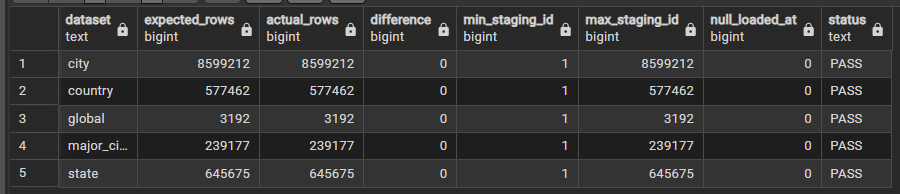

Kết quả cho thấy cả năm dataset đều có trạng thái `PASS` và `difference = 0`. Số dòng thực tế lần lượt là Global 3.192, Country 577.462, State 645.675, City 8.599.212 và Major City 239.177, hoàn toàn khớp với số dòng mong đợi trước bước cắt.

Ở mỗi bảng, `min_staging_id = 1`, `max_staging_id = actual_rows` và `null_loaded_at = 0`. Điều này xác nhận dữ liệu đã được import đầy đủ trong lần nạp hiện tại, dải khóa staging liên tục và tất cả bản ghi đều có thời điểm nạp.

### 7.2. Kiểm tra schema và primary key của staging tables

In [ ]:
-- Kiểm tra kiểu dữ liệu của 5 staging tables.
SELECT
    table_name,
    ordinal_position,
    column_name,
    data_type,
    is_nullable,
    column_default
FROM information_schema.columns
WHERE table_schema = 'public'
  AND table_name IN (
      'staging_global',
      'staging_country',
      'staging_state',
      'staging_city',
      'staging_major_city'
  )
ORDER BY table_name, ordinal_position;

-- Kiểm tra primary key của staging tables.
SELECT
    tc.table_name,
    tc.constraint_name,
    kcu.column_name
FROM information_schema.table_constraints AS tc
JOIN information_schema.key_column_usage AS kcu
  ON kcu.constraint_schema = tc.constraint_schema
 AND kcu.constraint_name = tc.constraint_name
WHERE tc.table_schema = 'public'
  AND tc.constraint_type = 'PRIMARY KEY'
  AND tc.table_name LIKE 'staging_%'
ORDER BY tc.table_name;


Cell gồm hai truy vấn đọc metadata hệ thống của PostgreSQL. Truy vấn thứ nhất đọc `information_schema.columns` để liệt kê tên bảng, vị trí cột, tên cột, kiểu dữ liệu, khả năng nhận `NULL` và giá trị mặc định của năm staging tables. Kết quả này dùng để đối chiếu cấu trúc thực tế với các lệnh `CREATE TABLE` ở Mục 5.

Truy vấn thứ hai kết hợp `information_schema.table_constraints` với `information_schema.key_column_usage` để tìm các constraint loại `PRIMARY KEY`. Mỗi staging table phải có đúng một primary key trên cột `staging_id`, giúp định danh duy nhất và duy trì data lineage cho các bước sau.

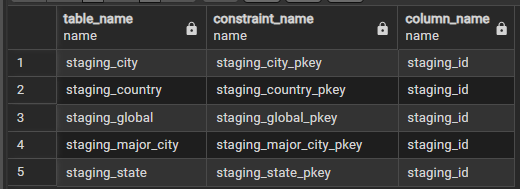

Ảnh kết quả hiển thị đúng năm staging tables. Mỗi bảng có một constraint primary key với tên tương ứng như `staging_city_pkey`, `staging_country_pkey` và đều sử dụng cột `staging_id`. Vì vậy, phần kiểm tra primary key đạt yêu cầu.

Do cell chứa hai câu `SELECT`, pgAdmin đang hiển thị Data Output của câu truy vấn cuối cùng, tức kết quả primary key. Ảnh này chưa thể hiện danh sách cột và kiểu dữ liệu từ truy vấn đầu tiên. Khi cần lưu bằng chứng kiểm tra schema, hãy chạy riêng câu `SELECT` từ `information_schema.columns` và chụp kết quả của truy vấn đó.

### 7.3. Kiểm tra duplicate theo grain nghiệp vụ

In [ ]:
-- Duplicate theo grain nghiệp vụ; giá trị 0 là kết quả mong đợi.
SELECT
    'global' AS dataset,
    COUNT(*) - COUNT(DISTINCT (dt)) AS duplicate_business_keys
FROM staging_global
UNION ALL
SELECT
    'country',
    COUNT(*) - COUNT(DISTINCT (dt, country))
FROM staging_country
UNION ALL
SELECT
    'state',
    COUNT(*) - COUNT(DISTINCT (dt, state, country))
FROM staging_state
UNION ALL
SELECT
    'city',
    COUNT(*) - COUNT(DISTINCT (dt, city, country, latitude, longitude))
FROM staging_city
UNION ALL
SELECT
    'major_city',
    COUNT(*) - COUNT(DISTINCT (dt, city, country, latitude, longitude))
FROM staging_major_city
ORDER BY dataset;


Truy vấn xác định số bản ghi trùng bằng cách lấy tổng số dòng trừ số tổ hợp khóa nghiệp vụ phân biệt. Khóa được chọn theo grain của từng dataset: Global dùng `dt`; Country dùng `dt, country`; State dùng `dt, state, country`; City và Major City dùng `dt, city, country, latitude, longitude`.

Cột `duplicate_business_keys` biểu thị số dòng dư thừa so với các tổ hợp khóa duy nhất. Kết quả mong đợi là `0` cho cả năm dataset. Kiểm tra này chỉ phát hiện trùng theo grain đã định nghĩa và không thay thế các kiểm tra missing values hoặc chuẩn hóa tên địa lý ở Notebook 03.

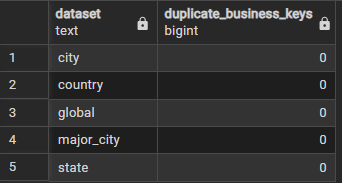

Kết quả cho thấy `duplicate_business_keys = 0` ở cả Global, Country, State, City và Major City. Như vậy, không có bản ghi lặp theo grain nghiệp vụ đã xác định trong dữ liệu staging sau import.

Kết hợp với trạng thái `PASS` của Mục 7.1 và primary key hợp lệ ở Mục 7.2, staging layer đã đạt các điều kiện kiểm tra ban đầu về số lượng, khả năng truy vết và tính duy nhất. Dữ liệu có thể chuyển sang bước cắt City tại Mục 8 trước khi xây dựng analytical layer và bàn giao cho Notebook 03.

## 8. Tiến hành cắt dữ liệu file `GlobalLandTemperaturesByCity.csv`

Mục này cắt dữ liệu **trực tiếp trên `staging_city`** theo hai bước: chỉ giữ lại khoảng một nửa số quốc gia có trong dữ liệu, sau đó chỉ giữ thời gian từ `1863-01-01` đến trước `2014-01-01`. Các dòng thiếu nhiệt độ vẫn được giữ lại để Notebook 03 xử lý theo đúng trách nhiệm data cleaning.

Sau mỗi lệnh `DELETE`, một khối validation chạy ngay trong transaction. Nếu số dòng hoặc số quốc gia không đúng, PostgreSQL phát sinh exception để ngăn `COMMIT`; khi đó cần chạy `ROLLBACK;`. Sau khi commit thành công, `staging_city` chỉ còn 5.010.113 dòng và được dùng trực tiếp từ Mục 9 trở đi. Thao tác này không thể hoàn tác sau `COMMIT` nếu không import lại CSV nguyên bản, vì vậy chỉ chạy sau khi Mục 7 đã đạt yêu cầu.

### 8.1. Cắt theo tên quốc gia

#### 8.1.1. Kiểm tra số quốc gia có trong dữ liệu

In [ ]:
-- Danh sách 20 quốc gia lớn/bắt buộc theo yêu cầu của bước cắt dữ liệu.
WITH mandatory_countries(country) AS (
    VALUES
        ('Vietnam'), ('United States'), ('China'), ('India'), ('Russia'),
        ('Brazil'), ('Japan'), ('Germany'), ('United Kingdom'), ('France'),
        ('Canada'), ('Australia'), ('Italy'), ('South Korea'), ('Mexico'),
        ('Indonesia'), ('Turkey'), ('Saudi Arabia'), ('Spain'), ('South Africa')
),
source_countries AS (
    SELECT DISTINCT country
    FROM staging_city
    WHERE NULLIF(BTRIM(country), '') IS NOT NULL
),
source_stats AS (
    SELECT
        COUNT(*) AS source_rows,
        COUNT(*) FILTER (
            WHERE NULLIF(BTRIM(country), '') IS NULL
        ) AS invalid_country_rows
    FROM staging_city
)
SELECT
    s.source_rows,
    (SELECT COUNT(*) FROM source_countries) AS distinct_countries,
    s.invalid_country_rows,
    (
        SELECT COUNT(*)
        FROM mandatory_countries AS m
        JOIN source_countries AS c USING (country)
    ) AS mandatory_countries_found,
    ARRAY(
        SELECT m.country
        FROM mandatory_countries AS m
        LEFT JOIN source_countries AS c USING (country)
        WHERE c.country IS NULL
        ORDER BY m.country
    ) AS missing_mandatory_countries
FROM source_stats AS s;

Truy vấn kiểm tra quy mô và độ phủ quốc gia của dữ liệu City nguyên bản trước khi thực hiện lọc. `invalid_country_rows` đếm các dòng có quốc gia `NULL` hoặc chuỗi rỗng.

Hai cột cuối xác minh đầy đủ 20 quốc gia bắt buộc: `mandatory_countries_found` phải bằng `20` và `missing_mandatory_countries` phải là mảng rỗng `{}`. Nếu thiếu bất kỳ quốc gia nào, không nên chạy Mục 8.1.2 vì tập kết quả sẽ không đáp ứng tiêu chí lựa chọn ban đầu.

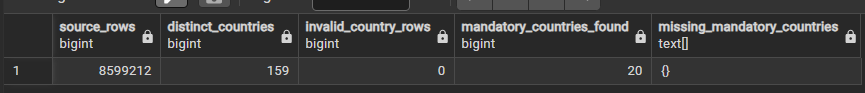

Kết quả xác nhận bảng `staging_city` trước khi cắt có **8.599.212 dòng** thuộc **159 quốc gia**. Không có dòng nào thiếu hoặc rỗng tên quốc gia (`invalid_country_rows = 0`), vì vậy điều kiện lọc theo quốc gia có thể áp dụng một cách đầy đủ.

Cả **20/20 quốc gia bắt buộc** đều xuất hiện và `missing_mandatory_countries` là mảng rỗng `{}`. Đây là điều kiện cần để tiếp tục bước 8.1.2: danh sách 80 quốc gia mục tiêu sẽ luôn giữ đủ nhóm quốc gia bắt buộc như thiết kế.

#### 8.1.2. Cắt dữ liệu giữ lại 80 quốc gia

In [ ]:
BEGIN;

-- Tạo lại manifest quốc gia dùng cho thao tác cắt trực tiếp.
DROP TABLE IF EXISTS city_target_countries;

-- Lưu cố định 80 quốc gia để kết quả không thay đổi giữa các lần chạy.
CREATE TABLE city_target_countries (
    country TEXT PRIMARY KEY,
    selection_group TEXT NOT NULL CHECK (
        selection_group IN ('mandatory', 'additional')
    )
);

INSERT INTO city_target_countries (country, selection_group)
VALUES
    ('Vietnam', 'mandatory'),
    ('United States', 'mandatory'),
    ('China', 'mandatory'),
    ('India', 'mandatory'),
    ('Russia', 'mandatory'),
    ('Brazil', 'mandatory'),
    ('Japan', 'mandatory'),
    ('Germany', 'mandatory'),
    ('United Kingdom', 'mandatory'),
    ('France', 'mandatory'),
    ('Canada', 'mandatory'),
    ('Australia', 'mandatory'),
    ('Italy', 'mandatory'),
    ('South Korea', 'mandatory'),
    ('Mexico', 'mandatory'),
    ('Indonesia', 'mandatory'),
    ('Turkey', 'mandatory'),
    ('Saudi Arabia', 'mandatory'),
    ('Spain', 'mandatory'),
    ('South Africa', 'mandatory'),
    ('Algeria', 'additional'),
    ('Angola', 'additional'),
    ('Azerbaijan', 'additional'),
    ('Bahrain', 'additional'),
    ('Bangladesh', 'additional'),
    ('Bolivia', 'additional'),
    ('Botswana', 'additional'),
    ('Burundi', 'additional'),
    ('Cameroon', 'additional'),
    ('Chad', 'additional'),
    ('Colombia', 'additional'),
    ('Congo (Democratic Republic Of The)', 'additional'),
    ('Costa Rica', 'additional'),
    ('Denmark', 'additional'),
    ('Djibouti', 'additional'),
    ('Ecuador', 'additional'),
    ('El Salvador', 'additional'),
    ('Eritrea', 'additional'),
    ('Finland', 'additional'),
    ('Gabon', 'additional'),
    ('Ghana', 'additional'),
    ('Guinea Bissau', 'additional'),
    ('Haiti', 'additional'),
    ('Iran', 'additional'),
    ('Iraq', 'additional'),
    ('Kazakhstan', 'additional'),
    ('Laos', 'additional'),
    ('Lebanon', 'additional'),
    ('Lesotho', 'additional'),
    ('Libya', 'additional'),
    ('Lithuania', 'additional'),
    ('Macedonia', 'additional'),
    ('Madagascar', 'additional'),
    ('Malaysia', 'additional'),
    ('Mauritius', 'additional'),
    ('Moldova', 'additional'),
    ('Mozambique', 'additional'),
    ('New Zealand', 'additional'),
    ('Nicaragua', 'additional'),
    ('Norway', 'additional'),
    ('Oman', 'additional'),
    ('Panama', 'additional'),
    ('Poland', 'additional'),
    ('Romania', 'additional'),
    ('Rwanda', 'additional'),
    ('Serbia', 'additional'),
    ('Sierra Leone', 'additional'),
    ('Slovakia', 'additional'),
    ('Slovenia', 'additional'),
    ('Sudan', 'additional'),
    ('Swaziland', 'additional'),
    ('Switzerland', 'additional'),
    ('Syria', 'additional'),
    ('Togo', 'additional'),
    ('Turkmenistan', 'additional'),
    ('Ukraine', 'additional'),
    ('Uruguay', 'additional'),
    ('Uzbekistan', 'additional'),
    ('Yemen', 'additional'),
    ('Zambia', 'additional');

-- Dừng transaction nếu danh sách không có đúng 20 + 60 quốc gia.
DO $$
DECLARE
    total_count INTEGER;
    mandatory_count INTEGER;
BEGIN
    SELECT
        COUNT(*),
        COUNT(*) FILTER (WHERE selection_group = 'mandatory')
    INTO total_count, mandatory_count
    FROM city_target_countries;

    IF total_count <> 80 OR mandatory_count <> 20 THEN
        RAISE EXCEPTION
            'Danh sách mục tiêu không hợp lệ: tổng %, bắt buộc %.',
            total_count, mandatory_count;
    END IF;
END
$$;

-- Xóa trực tiếp các dòng không thuộc danh sách 80 quốc gia.
DELETE FROM staging_city AS s
WHERE NOT EXISTS (
    SELECT 1
    FROM city_target_countries AS t
    WHERE t.country = s.country
);

-- Không cho phép commit nếu kết quả lọc quốc gia sai data contract.
DO $$
DECLARE
    remaining_rows BIGINT;
    remaining_countries INTEGER;
    mandatory_retained INTEGER;
BEGIN
    SELECT COUNT(*), COUNT(DISTINCT country)
    INTO remaining_rows, remaining_countries
    FROM staging_city;

    SELECT COUNT(DISTINCT s.country)
    INTO mandatory_retained
    FROM staging_city AS s
    JOIN city_target_countries AS t USING (country)
    WHERE t.selection_group = 'mandatory';

    IF remaining_rows <> 6907065
       OR remaining_countries <> 80
       OR mandatory_retained <> 20 THEN
        RAISE EXCEPTION
            'Lọc quốc gia sai data contract: rows %, countries %, mandatory %.',
            remaining_rows, remaining_countries, mandatory_retained;
    END IF;
END
$$;

COMMIT;

ANALYZE staging_city;

-- Kiểm tra kết quả sau khi chỉ lọc theo quốc gia.
SELECT
    COUNT(*) AS rows_after_country_filter,
    COUNT(DISTINCT country) AS selected_countries,
    COUNT(DISTINCT country) FILTER (
        WHERE country IN (
            SELECT country
            FROM city_target_countries
            WHERE selection_group = 'mandatory'
        )
    ) AS mandatory_countries_retained,
    MIN(dt) AS min_date,
    MAX(dt) AS max_date,
    COUNT(*) FILTER (WHERE average_temperature IS NULL)
        AS missing_temperature_rows,
    CASE
        WHEN COUNT(*) = 6907065
         AND COUNT(DISTINCT country) = 80
         AND COUNT(DISTINCT country) FILTER (
             WHERE country IN (
                 SELECT country
                 FROM city_target_countries
                 WHERE selection_group = 'mandatory'
             )
         ) = 20
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM staging_city;

Cell tạo bảng `city_target_countries` như một manifest cố định thay cho `ORDER BY RANDOM()`. Hai nhãn `mandatory` và `additional` giúp chứng minh danh sách gồm đúng 20 quốc gia bắt buộc và 60 quốc gia bổ sung. Khối `DO` dừng transaction nếu số lượng này bị thay đổi ngoài ý muốn.

Sau đó, `DELETE ... WHERE NOT EXISTS` xóa trực tiếp khỏi `staging_city` các dòng không thuộc manifest. Kết quả mong đợi là 6.907.065 dòng còn lại, 80 quốc gia, đủ 20 quốc gia bắt buộc, thời gian từ `1743-11-01` đến `2013-09-01` và trạng thái `PASS`. `missing_temperature_rows` không cần bằng 0 vì Mục 8 chưa thực hiện data cleaning.

Các `staging_id` còn lại vẫn giữ giá trị ban đầu nên có thể xuất hiện khoảng trống sau `DELETE`; điều này là bình thường và giúp duy trì data lineage về lần import gốc. Nếu validation phát sinh exception, transaction chưa được commit và cần chạy `ROLLBACK;` trước khi sửa nguyên nhân hoặc thử lại.

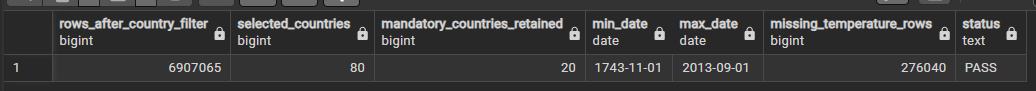

Bước lọc theo quốc gia đã hoàn tất thành công (`status = PASS`). `staging_city` còn **6.907.065 dòng**, tương ứng với **80 quốc gia** trong manifest; toàn bộ **20 quốc gia bắt buộc** đều được giữ lại. So với dữ liệu ban đầu, **1.692.147 dòng** của các quốc gia ngoài phạm vi đã được loại bỏ trực tiếp khỏi bảng staging.

Dải thời gian vẫn giữ nguyên từ `1743-11-01` đến `2013-09-01`, chứng tỏ bước này chỉ tác động đến tiêu chí quốc gia. Có **276.040 dòng** thiếu `average_temperature`; đây là dữ liệu thiếu được chủ động bảo toàn để Notebook 03 thực hiện làm sạch, không phải lỗi của thao tác cắt.

### 8.2. Cắt theo giai đoạn thời gian 1863–2013

#### 8.2.1. Kiểm tra dải thời gian

In [ ]:
-- Đánh giá dải thời gian trước khi tạo bảng City cuối cùng.
SELECT
    COUNT(*) AS rows_before_time_filter,
    MIN(dt) AS min_date_before_filter,
    MAX(dt) AS max_date_before_filter,
    COUNT(DISTINCT dt) AS distinct_dates_before_filter,
    COUNT(*) FILTER (WHERE dt IS NULL) AS null_date_rows
FROM staging_city;

Truy vấn chưa xóa thêm dữ liệu mà chỉ đo phạm vi thời gian của `staging_city` sau bước lọc quốc gia. Kết quả mong đợi gồm 6.907.065 dòng, 3.239 tháng phân biệt, ngày nhỏ nhất `1743-11-01`, ngày lớn nhất `2013-09-01` và không có `dt` bị `NULL`.

Khoảng lọc được biểu diễn theo dạng nửa mở: từ `1863-01-01` trở đi và nhỏ hơn `2014-01-01`. Cách viết này bao phủ toàn bộ năm 2013 mà không phụ thuộc ngày cuối tháng.

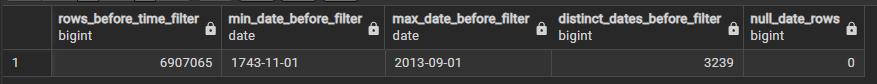

Sau khi giữ 80 quốc gia, bảng có **6.907.065 dòng** trải trên **3.239 mốc tháng**, từ `1743-11-01` đến `2013-09-01`; `null_date_rows = 0` cho thấy cột ngày có thể dùng an toàn làm điều kiện lọc.

Khi áp dụng khoảng thời gian mục tiêu từ `1863-01-01` đến trước `2014-01-01`. Dữ liệu nguồn chỉ có đến tháng 09/2013, do đó mốc kết thúc thực tế sau khi lọc sẽ là `2013-09-01`, không phải cuối tháng 12/2013.

#### 8.2.2. Tạo tập City cuối trong giai đoạn 1863–2013

In [ ]:
BEGIN;

-- Xóa trực tiếp các dòng nằm ngoài giai đoạn mục tiêu.
DELETE FROM staging_city
WHERE dt < DATE '1863-01-01'
   OR dt >= DATE '2014-01-01'
   OR dt IS NULL;

-- Không cho phép commit nếu kết quả cuối sai data contract.
DO $$
DECLARE
    checked_rows BIGINT;
    checked_countries BIGINT;
    checked_dates BIGINT;
    checked_min_date DATE;
    checked_max_date DATE;
    checked_missing_temperature BIGINT;
    checked_invalid_dates BIGINT;
BEGIN
    SELECT
        COUNT(*),
        COUNT(DISTINCT country),
        COUNT(DISTINCT dt),
        MIN(dt),
        MAX(dt),
        COUNT(*) FILTER (WHERE average_temperature IS NULL),
        COUNT(*) FILTER (
            WHERE dt < DATE '1863-01-01'
               OR dt >= DATE '2014-01-01'
               OR dt IS NULL
        )
    INTO
        checked_rows,
        checked_countries,
        checked_dates,
        checked_min_date,
        checked_max_date,
        checked_missing_temperature,
        checked_invalid_dates
    FROM staging_city;

    IF checked_rows <> 5010113
       OR checked_countries <> 80
       OR checked_dates <> 1809
       OR checked_min_date <> DATE '1863-01-01'
       OR checked_max_date <> DATE '2013-09-01'
       OR checked_missing_temperature <> 43101
       OR checked_invalid_dates <> 0 THEN
        RAISE EXCEPTION
            'Cắt thời gian sai data contract: rows %, countries %, dates %, min %, max %, missing %, invalid %.',
            checked_rows, checked_countries, checked_dates,
            checked_min_date, checked_max_date,
            checked_missing_temperature, checked_invalid_dates;
    END IF;
END
$$;

COMMIT;

ANALYZE staging_city;

-- Xác nhận data contract cuối của bước cắt dữ liệu.
WITH validation AS (
    SELECT
        COUNT(*) AS final_rows,
        COUNT(DISTINCT country) AS final_countries,
        COUNT(DISTINCT dt) AS final_distinct_dates,
        MIN(dt) AS final_min_date,
        MAX(dt) AS final_max_date,
        COUNT(*) FILTER (WHERE average_temperature IS NULL)
            AS missing_temperature_rows,
        COUNT(*) FILTER (
            WHERE dt < DATE '1863-01-01'
               OR dt >= DATE '2014-01-01'
               OR dt IS NULL
        ) AS invalid_date_rows
    FROM staging_city
)
SELECT
    final_rows,
    final_countries,
    final_distinct_dates,
    final_min_date,
    final_max_date,
    missing_temperature_rows,
    invalid_date_rows,
    CASE
        WHEN final_rows = 5010113
         AND final_countries = 80
         AND final_distinct_dates = 1809
         AND final_min_date = DATE '1863-01-01'
         AND final_max_date = DATE '2013-09-01'
         AND missing_temperature_rows = 43101
         AND invalid_date_rows = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM validation;

Cell dùng `DELETE` trực tiếp trên `staging_city` để loại các dòng trước `1863-01-01`, từ `2014-01-01` trở đi hoặc có ngày bị `NULL`. Các cột nhiệt độ bị `NULL` không nằm trong điều kiện xóa nên vẫn được bảo toàn. Primary key `staging_id` và các giá trị ID gốc không bị tạo lại; sau khi xóa, việc ID có khoảng trống là kết quả bình thường.

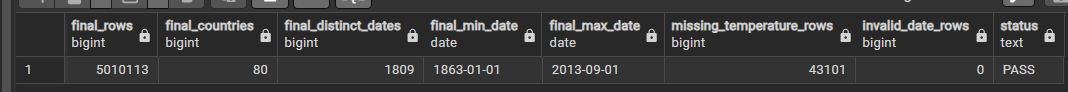

Kết quả cuối cùng đạt `status = PASS`: `staging_city` còn **5.010.113 dòng**, giữ nguyên **80 quốc gia** và **1.809 mốc tháng**. Dải ngày là `1863-01-01` đến `2013-09-01`, đồng thời `invalid_date_rows = 0`, nên tất cả bản ghi còn lại đều nằm trong phạm vi thời gian đã xác định.

Có **43.101 dòng** chưa có `average_temperature`. Các dòng này không bị xóa vì bước hiện tại chỉ giảm quy mô theo quốc gia và thời gian; việc đánh giá, xử lý hoặc nội suy giá trị thiếu thuộc phạm vi của Notebook 03. Tập `staging_city` này là đầu vào đã cắt quy mô để sử dụng cho các bước mô hình hóa/join ở Mục 9 và làm sạch dữ liệu tiếp theo.

## 9. Chuẩn hóa và nạp dimension/fact

Global, Country, State và Major City đọc từ staging tables sau import. Riêng `staging_city` đã được cắt trực tiếp và kiểm tra ở Mục 8, vì vậy bảng này chứa 5.010.113 dòng thuộc 80 quốc gia trong giai đoạn 1863–2013. Mục này tạo analytical layer theo mô hình sao:

- Dimensions: date, country, state, city.
- Facts: global, country, state, city, major city.
- Tọa độ N/S/E/W được chuyển thành số có dấu.
- source_staging_id được giữ trong mọi fact.

### 9.1. Tạo các bảng dimension

#### 9.1.1. Tạo dimension thời gian `dim_date`

In [ ]:
CREATE TABLE dim_date (
    date_id BIGSERIAL PRIMARY KEY,
    full_date DATE NOT NULL UNIQUE,
    year SMALLINT NOT NULL,
    month SMALLINT NOT NULL CHECK (month BETWEEN 1 AND 12),
    quarter SMALLINT NOT NULL CHECK (quarter BETWEEN 1 AND 4),
    decade SMALLINT NOT NULL
);

`dim_date` lưu một bản ghi duy nhất cho mỗi mốc thời gian xuất hiện trong các nguồn. Các thuộc tính `year`, `month`, `quarter` và `decade` được tạo sẵn để phục vụ phân tích theo thời gian mà không cần tính lại trong mỗi truy vấn.

Ràng buộc `UNIQUE (full_date)` bảo đảm mỗi mốc thời gian chỉ có một `date_id`; các fact table sẽ dùng khóa này để join.

#### 9.1.2. Tạo dimension quốc gia `dim_country`

In [ ]:
CREATE TABLE dim_country (
    country_id BIGSERIAL PRIMARY KEY,
    country_name TEXT NOT NULL UNIQUE,
    CHECK (BTRIM(country_name) <> '')
);

`dim_country` chuẩn hóa tên quốc gia thành một thực thể dùng chung cho dữ liệu quốc gia, bang/tỉnh và thành phố. `country_name` là duy nhất, còn `country_id` là khóa được dùng trong các bảng phụ thuộc.

Điều kiện `CHECK (BTRIM(country_name) <> '')` ngăn việc lưu tên quốc gia chỉ gồm khoảng trắng.

#### 9.1.3. Tạo dimension bang/tỉnh `dim_state`

In [ ]:
CREATE TABLE dim_state (
    state_id BIGSERIAL PRIMARY KEY,
    state_name TEXT NOT NULL,
    country_id BIGINT NOT NULL REFERENCES dim_country(country_id),
    UNIQUE (state_name, country_id),
    CHECK (BTRIM(state_name) <> '')
);

`dim_state` lưu bang/tỉnh cùng quốc gia sở hữu thông qua `country_id`. Một tên bang/tỉnh có thể trùng ở các quốc gia khác nhau, vì vậy khóa duy nhất được đặt trên cặp `(state_name, country_id)`.

Khóa ngoại đến `dim_country` duy trì quan hệ phân cấp quốc gia → bang/tỉnh và ngăn dữ liệu mồ côi.

#### 9.1.4. Tạo dimension thành phố `dim_city`

In [ ]:
CREATE TABLE dim_city (
    city_id BIGSERIAL PRIMARY KEY,
    city_name TEXT NOT NULL,
    country_id BIGINT NOT NULL REFERENCES dim_country(country_id),
    latitude DOUBLE PRECISION NOT NULL CHECK (latitude BETWEEN -90 AND 90),
    longitude DOUBLE PRECISION NOT NULL CHECK (longitude BETWEEN -180 AND 180),
    is_major_city BOOLEAN NOT NULL DEFAULT FALSE,
    UNIQUE (city_name, country_id, latitude, longitude),
    CHECK (BTRIM(city_name) <> '')
);

`dim_city` định danh thành phố bằng tên, quốc gia và tọa độ đã được chuẩn hóa thành số có dấu. Cách định danh này phân biệt các thành phố trùng tên hoặc các vị trí khác nhau trong cùng một quốc gia.

Cột `is_major_city` đánh dấu những thành phố cũng xuất hiện trong nguồn Major City. Ràng buộc miền giá trị bảo đảm vĩ độ thuộc `[-90, 90]` và kinh độ thuộc `[-180, 180]`.

### 9.2. Tạo các bảng fact nhiệt độ

#### 9.2.1. Tạo fact nhiệt độ toàn cầu

In [ ]:
CREATE TABLE fact_global_temperature (
    global_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    land_average_temperature DOUBLE PRECISION,
    land_average_temperature_uncertainty DOUBLE PRECISION,
    land_max_temperature DOUBLE PRECISION,
    land_max_temperature_uncertainty DOUBLE PRECISION,
    land_min_temperature DOUBLE PRECISION,
    land_min_temperature_uncertainty DOUBLE PRECISION,
    land_and_ocean_average_temperature DOUBLE PRECISION,
    land_and_ocean_average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id)
);

`fact_global_temperature` lưu các chỉ số nhiệt độ đất, cực đại, cực tiểu và đất–đại dương theo từng mốc thời gian. `UNIQUE (date_id)` phản ánh grain của nguồn Global: mỗi tháng có tối đa một quan sát toàn cầu.

`source_staging_id` giữ định danh của dòng nhập ban đầu và là duy nhất, nhờ đó có thể truy vết về `staging_global` cũng như phát hiện nạp trùng.

#### 9.2.2. Tạo fact nhiệt độ theo quốc gia

In [ ]:
CREATE TABLE fact_country_temperature (
    country_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    country_id BIGINT NOT NULL REFERENCES dim_country(country_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id, country_id)
);

`fact_country_temperature` có grain là một quan sát nhiệt độ của một quốc gia tại một mốc thời gian. Hai khóa ngoại `date_id` và `country_id` kết nối số đo với các dimension tương ứng.

Ràng buộc `UNIQUE (date_id, country_id)` ngăn một quốc gia có hai bản ghi cho cùng một tháng; `source_staging_id` bảo toàn khả năng truy vết dòng nguồn.

#### 9.2.3. Tạo fact nhiệt độ theo bang/tỉnh

In [ ]:
CREATE TABLE fact_state_temperature (
    state_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    state_id BIGINT NOT NULL REFERENCES dim_state(state_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id, state_id)
);

`fact_state_temperature` lưu nhiệt độ trung bình và độ bất định cho từng bang/tỉnh theo tháng. `state_id` đã liên kết gián tiếp tới quốc gia qua `dim_state`, nên không cần lặp lại `country_id` trong fact table.

Cặp `(date_id, state_id)` biểu diễn duy nhất một quan sát theo grain của nguồn State.

#### 9.2.4. Tạo fact nhiệt độ theo thành phố

In [ ]:
CREATE TABLE fact_city_temperature (
    city_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    city_id BIGINT NOT NULL REFERENCES dim_city(city_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id, city_id)
);

`fact_city_temperature` là bảng fact có quy mô lớn nhất, lưu một quan sát nhiệt độ của mỗi thành phố tại từng mốc thời gian. Nguồn nạp là `staging_city` đã được cắt còn 80 quốc gia và giai đoạn 1863–2013 ở Mục 8.

Khóa duy nhất `(date_id, city_id)` bảo vệ grain một thành phố–một tháng, còn `source_staging_id` giúp đối chiếu với dòng CSV đã nhập.

#### 9.2.5. Tạo fact nhiệt độ theo thành phố lớn

In [ ]:
CREATE TABLE fact_major_city_temperature (
    major_city_temperature_id BIGSERIAL PRIMARY KEY,
    date_id BIGINT NOT NULL REFERENCES dim_date(date_id),
    city_id BIGINT NOT NULL REFERENCES dim_city(city_id),
    source_staging_id BIGINT NOT NULL UNIQUE,
    average_temperature DOUBLE PRECISION,
    average_temperature_uncertainty DOUBLE PRECISION,
    UNIQUE (date_id, city_id)
);

`fact_major_city_temperature` có cùng grain thành phố–tháng nhưng chỉ cho tập thành phố lớn của nguồn Major City. Bảng dùng chung `dim_city` với dữ liệu City, nhờ đó có thể so sánh trực tiếp hai nguồn qua cùng khóa thành phố.

Ràng buộc trên `(date_id, city_id)` và `source_staging_id` giữ nguyên tắc không nạp trùng và khả năng truy vết nguồn.

### 9.3. Nạp dữ liệu vào các dimension

#### 9.3.1. Nạp các mốc thời gian

In [ ]:
INSERT INTO dim_date (full_date, year, month, quarter, decade)
SELECT
    full_date,
    EXTRACT(YEAR FROM full_date)::SMALLINT,
    EXTRACT(MONTH FROM full_date)::SMALLINT,
    EXTRACT(QUARTER FROM full_date)::SMALLINT,
    ((EXTRACT(YEAR FROM full_date)::INTEGER / 10) * 10)::SMALLINT
FROM (
    SELECT dt AS full_date FROM staging_global WHERE dt IS NOT NULL
    UNION
    SELECT dt FROM staging_country WHERE dt IS NOT NULL
    UNION
    SELECT dt FROM staging_state WHERE dt IS NOT NULL
    UNION
    SELECT dt FROM staging_city WHERE dt IS NOT NULL
    UNION
    SELECT dt FROM staging_major_city WHERE dt IS NOT NULL
) AS source_dates
ORDER BY full_date;

Lệnh dùng `UNION` để hợp nhất các ngày khác rỗng từ năm bảng staging, đồng thời tự loại trùng ngày. Mỗi ngày sau đó được tách thành năm, tháng, quý và thập niên trước khi nạp vào `dim_date`.

Nạp dimension thời gian trước các fact table bảo đảm mọi `dt` hợp lệ trong nguồn đều có `date_id` để join.

#### 9.3.2. Nạp danh sách quốc gia

In [ ]:
INSERT INTO dim_country (country_name)
SELECT country_name
FROM (
    SELECT NULLIF(BTRIM(country), '') AS country_name FROM staging_country
    UNION
    SELECT NULLIF(BTRIM(country), '') FROM staging_state
    UNION
    SELECT NULLIF(BTRIM(country), '') FROM staging_city
    UNION
    SELECT NULLIF(BTRIM(country), '') FROM staging_major_city
) AS source_countries
WHERE country_name IS NOT NULL
ORDER BY country_name;

Tên quốc gia được lấy từ bốn nguồn có trường quốc gia, loại bỏ khoảng trắng thừa bằng `BTRIM` và bỏ giá trị rỗng bằng `NULLIF`. `UNION` tạo một danh sách quốc gia không trùng trước khi nạp vào `dim_country`.

Do `staging_city` đã được cắt ở Mục 8, phần City chỉ đóng góp 80 quốc gia mục tiêu; các quốc gia còn lại vẫn có thể được bổ sung từ nguồn Country, State hoặc Major City.

#### 9.3.3. Nạp danh sách bang/tỉnh

In [ ]:
INSERT INTO dim_state (state_name, country_id)
SELECT DISTINCT BTRIM(s.state), c.country_id
FROM staging_state AS s
JOIN dim_country AS c
  ON c.country_name = BTRIM(s.country)
WHERE NULLIF(BTRIM(s.state), '') IS NOT NULL
ORDER BY BTRIM(s.state), c.country_id;

Các bang/tỉnh khác rỗng được lấy từ `staging_state` và join với `dim_country` để lấy `country_id`. `SELECT DISTINCT` loại các lặp lại của cùng một bang/tỉnh xuất hiện qua nhiều tháng.

Thứ tự nạp này yêu cầu `dim_country` đã được nạp thành công ở bước 9.3.2.

#### 9.3.4. Nạp danh sách thành phố và chuẩn hóa tọa độ

In [ ]:
WITH city_source AS (
    SELECT
        NULLIF(BTRIM(s.city), '') AS city_name,
        NULLIF(BTRIM(s.country), '') AS country_name,
        CASE
            WHEN BTRIM(s.latitude) ~ '^[0-9]+([.][0-9]+)?[NS]$'
            THEN LEFT(BTRIM(s.latitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.latitude), 1)
                       WHEN 'S' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS latitude,
        CASE
            WHEN BTRIM(s.longitude) ~ '^[0-9]+([.][0-9]+)?[EW]$'
            THEN LEFT(BTRIM(s.longitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.longitude), 1)
                       WHEN 'W' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS longitude,
        FALSE AS is_major_city
    FROM staging_city AS s

    UNION ALL

    SELECT
        NULLIF(BTRIM(s.city), ''),
        NULLIF(BTRIM(s.country), ''),
        CASE
            WHEN BTRIM(s.latitude) ~ '^[0-9]+([.][0-9]+)?[NS]$'
            THEN LEFT(BTRIM(s.latitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.latitude), 1)
                       WHEN 'S' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END,
        CASE
            WHEN BTRIM(s.longitude) ~ '^[0-9]+([.][0-9]+)?[EW]$'
            THEN LEFT(BTRIM(s.longitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.longitude), 1)
                       WHEN 'W' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END,
        TRUE
    FROM staging_major_city AS s
)
INSERT INTO dim_city (
    city_name,
    country_id,
    latitude,
    longitude,
    is_major_city
)
SELECT
    cs.city_name,
    c.country_id,
    cs.latitude,
    cs.longitude,
    BOOL_OR(cs.is_major_city)
FROM city_source AS cs
JOIN dim_country AS c
  ON c.country_name = cs.country_name
WHERE cs.city_name IS NOT NULL
  AND cs.country_name IS NOT NULL
  AND cs.latitude IS NOT NULL
  AND cs.longitude IS NOT NULL
GROUP BY
    cs.city_name,
    c.country_id,
    cs.latitude,
    cs.longitude
ORDER BY
    cs.city_name,
    c.country_id,
    cs.latitude,
    cs.longitude;

Truy vấn hợp nhất City và Major City, đồng thời chuyển tọa độ dạng chuỗi như `10.5S` hoặc `106.7E` thành số có dấu: Nam/Tây là âm, Bắc/Đông là dương. Biểu thức chính quy chỉ cho phép các định dạng tọa độ hợp lệ.

Sau khi join quốc gia, câu lệnh nhóm theo tên thành phố, quốc gia và tọa độ để tạo một thành phố duy nhất. `BOOL_OR(is_major_city)` đặt cờ `TRUE` nếu thành phố đó xuất hiện trong nguồn Major City. Các tên hoặc tọa độ không hợp lệ bị loại khỏi dimension thay vì tạo khóa không thể join.

### 9.4. Nạp dữ liệu vào các fact table

#### 9.4.1. Nạp fact nhiệt độ toàn cầu

In [ ]:
INSERT INTO fact_global_temperature (
    date_id,
    source_staging_id,
    land_average_temperature,
    land_average_temperature_uncertainty,
    land_max_temperature,
    land_max_temperature_uncertainty,
    land_min_temperature,
    land_min_temperature_uncertainty,
    land_and_ocean_average_temperature,
    land_and_ocean_average_temperature_uncertainty
)
SELECT
    d.date_id,
    s.staging_id,
    s.land_average_temperature,
    s.land_average_temperature_uncertainty,
    s.land_max_temperature,
    s.land_max_temperature_uncertainty,
    s.land_min_temperature,
    s.land_min_temperature_uncertainty,
    s.land_and_ocean_average_temperature,
    s.land_and_ocean_average_temperature_uncertainty
FROM staging_global AS s
JOIN dim_date AS d ON d.full_date = s.dt;

Mỗi dòng từ `staging_global` được join với `dim_date` theo `dt`, sau đó nạp các chỉ số nhiệt độ toàn cầu vào `fact_global_temperature`. `staging_id` được lưu thành `source_staging_id` để giữ liên kết đến dòng nguồn.

Vì dùng `INNER JOIN`, chỉ các dòng có mốc thời gian đã tồn tại trong `dim_date` mới được nạp; bước 9.3.1 bảo đảm điều kiện này.

#### 9.4.2. Nạp fact nhiệt độ theo quốc gia

In [ ]:
INSERT INTO fact_country_temperature (
    date_id,
    country_id,
    source_staging_id,
    average_temperature,
    average_temperature_uncertainty
)
SELECT
    d.date_id,
    c.country_id,
    s.staging_id,
    s.average_temperature,
    s.average_temperature_uncertainty
FROM staging_country AS s
JOIN dim_date AS d ON d.full_date = s.dt
JOIN dim_country AS c ON c.country_name = BTRIM(s.country);

Dữ liệu `staging_country` được join với `dim_date` và `dim_country` để thay thế ngày và tên quốc gia bằng các khóa ngoại. Hàm `BTRIM` được dùng nhất quán với lúc tạo dimension để tránh lỗi join do khoảng trắng thừa.

Sau khi nạp, mỗi dòng fact đại diện cho nhiệt độ trung bình và độ bất định của một quốc gia trong một tháng.

#### 9.4.3. Nạp fact nhiệt độ theo bang/tỉnh

In [ ]:
INSERT INTO fact_state_temperature (
    date_id,
    state_id,
    source_staging_id,
    average_temperature,
    average_temperature_uncertainty
)
SELECT
    d.date_id,
    st.state_id,
    s.staging_id,
    s.average_temperature,
    s.average_temperature_uncertainty
FROM staging_state AS s
JOIN dim_date AS d ON d.full_date = s.dt
JOIN dim_country AS c ON c.country_name = BTRIM(s.country)
JOIN dim_state AS st
  ON st.country_id = c.country_id
 AND st.state_name = BTRIM(s.state);

Dữ liệu State được nối theo chuỗi quan hệ ngày → quốc gia → bang/tỉnh để lấy đúng `date_id` và `state_id`. Điều kiện join của `dim_state` dùng cả `country_id` lẫn `state_name`, nhờ đó phân biệt được các bang/tỉnh đồng tên ở quốc gia khác nhau.

Mỗi dòng nạp vẫn giữ `source_staging_id` để có thể kiểm tra lại với bảng staging khi cần.

#### 9.4.4. Nạp fact nhiệt độ theo thành phố

In [ ]:
WITH normalized_city AS (
    SELECT
        s.staging_id,
        s.dt,
        s.average_temperature,
        s.average_temperature_uncertainty,
        BTRIM(s.city) AS city_name,
        BTRIM(s.country) AS country_name,
        CASE
            WHEN BTRIM(s.latitude) ~ '^[0-9]+([.][0-9]+)?[NS]$'
            THEN LEFT(BTRIM(s.latitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.latitude), 1)
                       WHEN 'S' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS latitude,
        CASE
            WHEN BTRIM(s.longitude) ~ '^[0-9]+([.][0-9]+)?[EW]$'
            THEN LEFT(BTRIM(s.longitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.longitude), 1)
                       WHEN 'W' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS longitude
    FROM staging_city AS s
)
INSERT INTO fact_city_temperature (
    date_id,
    city_id,
    source_staging_id,
    average_temperature,
    average_temperature_uncertainty
)
SELECT
    d.date_id,
    ci.city_id,
    n.staging_id,
    n.average_temperature,
    n.average_temperature_uncertainty
FROM normalized_city AS n
JOIN dim_date AS d ON d.full_date = n.dt
JOIN dim_country AS c ON c.country_name = n.country_name
JOIN dim_city AS ci
  ON ci.country_id = c.country_id
 AND ci.city_name = n.city_name
 AND ci.latitude = n.latitude
 AND ci.longitude = n.longitude;

CTE `normalized_city` áp dụng lại đúng quy tắc chuẩn hóa tên và tọa độ đã dùng khi tạo `dim_city`. Nhờ đó, mỗi dòng của `staging_city` có thể join chính xác với `dim_date`, `dim_country` và `dim_city` để lấy các khóa ngoại.

Nguồn của fact này là tập City đã cắt ở Mục 8; do đó kết quả kỳ vọng là **5.010.113 dòng**. Giá trị nhiệt độ `NULL`, nếu có, vẫn được nạp nguyên trạng để Notebook 03 xử lý.

#### 9.4.5. Nạp fact nhiệt độ theo thành phố lớn

In [ ]:
WITH normalized_major_city AS (
    SELECT
        s.staging_id,
        s.dt,
        s.average_temperature,
        s.average_temperature_uncertainty,
        BTRIM(s.city) AS city_name,
        BTRIM(s.country) AS country_name,
        CASE
            WHEN BTRIM(s.latitude) ~ '^[0-9]+([.][0-9]+)?[NS]$'
            THEN LEFT(BTRIM(s.latitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.latitude), 1)
                       WHEN 'S' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS latitude,
        CASE
            WHEN BTRIM(s.longitude) ~ '^[0-9]+([.][0-9]+)?[EW]$'
            THEN LEFT(BTRIM(s.longitude), -1)::DOUBLE PRECISION
                 * CASE RIGHT(BTRIM(s.longitude), 1)
                       WHEN 'W' THEN -1.0 ELSE 1.0
                   END
            ELSE NULL
        END AS longitude
    FROM staging_major_city AS s
)
INSERT INTO fact_major_city_temperature (
    date_id,
    city_id,
    source_staging_id,
    average_temperature,
    average_temperature_uncertainty
)
SELECT
    d.date_id,
    ci.city_id,
    n.staging_id,
    n.average_temperature,
    n.average_temperature_uncertainty
FROM normalized_major_city AS n
JOIN dim_date AS d ON d.full_date = n.dt
JOIN dim_country AS c ON c.country_name = n.country_name
JOIN dim_city AS ci
  ON ci.country_id = c.country_id
 AND ci.city_name = n.city_name
 AND ci.latitude = n.latitude
 AND ci.longitude = n.longitude;

Bước này có cùng cơ chế chuẩn hóa và join với bước 9.4.4, nhưng lấy dữ liệu từ `staging_major_city`. Việc dùng chung `dim_city` giúp một thành phố lớn có cùng định danh với bản ghi tương ứng trong nguồn City nếu tên, quốc gia và tọa độ trùng khớp.

Kết quả được đối chiếu theo số dòng ở Mục 9.5 để phát hiện bản ghi bị thiếu do không join được dimension hoặc bị nạp trùng.

### 9.5. Kiểm tra kết quả nạp dimension và fact

In [ ]:
WITH expected(dataset, expected_rows) AS (
    VALUES
        ('global', 3192::BIGINT),
        ('country', 577462::BIGINT),
        ('state', 645675::BIGINT),
        ('city', 5010113::BIGINT),
        ('major_city', 239177::BIGINT)
),
actual(dataset, fact_table, actual_rows) AS (
    SELECT
        'global',
        'fact_global_temperature',
        COUNT(*)
    FROM fact_global_temperature
    UNION ALL
    SELECT
        'country',
        'fact_country_temperature',
        COUNT(*)
    FROM fact_country_temperature
    UNION ALL
    SELECT
        'state',
        'fact_state_temperature',
        COUNT(*)
    FROM fact_state_temperature
    UNION ALL
    SELECT
        'city',
        'fact_city_temperature',
        COUNT(*)
    FROM fact_city_temperature
    UNION ALL
    SELECT
        'major_city',
        'fact_major_city_temperature',
        COUNT(*)
    FROM fact_major_city_temperature
)
SELECT
    e.dataset,
    a.fact_table,
    e.expected_rows,
    a.actual_rows,
    a.actual_rows - e.expected_rows AS difference,
    CASE
        WHEN a.actual_rows = e.expected_rows THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM expected AS e
JOIN actual AS a USING (dataset)
ORDER BY e.dataset;

-- Row count của dimensions để tham khảo.
SELECT 'dim_date' AS table_name, COUNT(*) AS row_count FROM dim_date
UNION ALL
SELECT 'dim_country', COUNT(*) FROM dim_country
UNION ALL
SELECT 'dim_state', COUNT(*) FROM dim_state
UNION ALL
SELECT 'dim_city', COUNT(*) FROM dim_city
ORDER BY table_name;

Truy vấn đầu tiên so sánh số dòng thực tế của năm fact table với số dòng kỳ vọng từ các bảng staging: Global 3.192, Country 577.462, State 645.675, City 5.010.113 và Major City 239.177. Mỗi dòng cần có `difference = 0` và `status = PASS`.

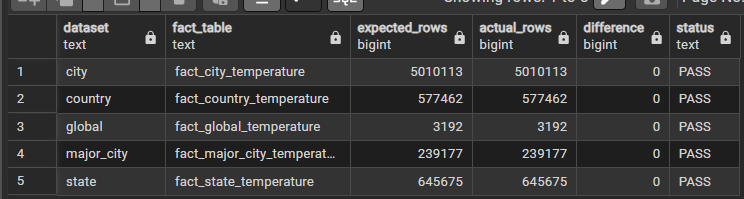

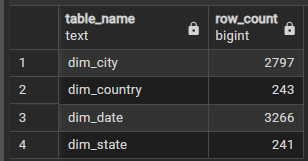

Kết quả validation xác nhận việc nạp cả năm fact table đều thành công. Số dòng thực tế khớp tuyệt đối với số dòng kỳ vọng: Global **3.192**, Country **577.462**, State **645.675**, City **5.010.113** và Major City **239.177**. Tất cả đều có `difference = 0` và `status = PASS`, cho thấy không có dòng bị mất hoặc bị nạp thừa trong quá trình join từ staging sang fact.

Các dimension cũng đã được tạo và nạp dữ liệu: `dim_date` có **3.266** mốc thời gian, `dim_country` có **243** quốc gia, `dim_state` có **241** bang/tỉnh và `dim_city` có **2.797** thành phố. Như vậy analytical layer đã sẵn sàng cho các monthly views, phép join và tổng hợp ở các mục tiếp theo.

## 10. Tạo monthly analytical views

Năm views dưới đây là lớp dữ liệu phẳng theo từng grain và là đầu vào chính của Notebook 03. Chúng giữ các dòng có nhiệt độ NULL, bổ sung thuộc tính thời gian/địa lý và giữ source_staging_id.

Không ghép cả năm cấp thành một bảng duy nhất vì điều đó làm sai grain và có thể gây row explosion.


### 10.1. Tạo các monthly analytical views

Các view được tạo sau khi Mục 9 đã nạp và kiểm tra thành công toàn bộ dimension/fact. Mỗi view giữ nguyên grain của một fact table, đồng thời bổ sung các thuộc tính mô tả từ dimension để Notebook 03 có thể truy vấn trực tiếp.

#### 10.1.1. Tạo view nhiệt độ toàn cầu

In [ ]:
CREATE OR REPLACE VIEW vw_global_temperature AS
SELECT
    f.global_temperature_id,
    f.source_staging_id,
    d.date_id,
    d.full_date AS observation_date,
    d.year,
    d.month,
    d.quarter,
    d.decade,
    f.land_average_temperature,
    f.land_average_temperature_uncertainty,
    f.land_max_temperature,
    f.land_max_temperature_uncertainty,
    f.land_min_temperature,
    f.land_min_temperature_uncertainty,
    f.land_and_ocean_average_temperature,
    f.land_and_ocean_average_temperature_uncertainty
FROM fact_global_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id;

`vw_global_temperature` giữ grain một quan sát toàn cầu theo tháng. View bổ sung các thuộc tính thời gian từ `dim_date` và giữ đầy đủ các chỉ số nhiệt độ đất, cực đại, cực tiểu và đất–đại dương từ fact table.

#### 10.1.2. Tạo view nhiệt độ theo quốc gia

In [ ]:
CREATE OR REPLACE VIEW vw_country_temperature AS
SELECT
    f.country_temperature_id, f.source_staging_id,
    d.date_id, d.full_date AS observation_date, d.year, d.month, d.quarter, d.decade,
    c.country_id, c.country_name,
    f.average_temperature, f.average_temperature_uncertainty
FROM fact_country_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id
JOIN dim_country AS c ON c.country_id = f.country_id;

`vw_country_temperature` biểu diễn một quốc gia tại một mốc thời gian. Việc join `dim_date` và `dim_country` giúp các truy vấn phân tích dùng trực tiếp ngày, thuộc tính thời gian và tên quốc gia thay vì chỉ dùng khóa số.

#### 10.1.3. Tạo view nhiệt độ theo bang/tỉnh

In [ ]:
CREATE OR REPLACE VIEW vw_state_temperature AS
SELECT
    f.state_temperature_id, f.source_staging_id,
    d.date_id, d.full_date AS observation_date, d.year, d.month, d.quarter, d.decade,
    s.state_id, s.state_name, c.country_id, c.country_name,
    f.average_temperature, f.average_temperature_uncertainty
FROM fact_state_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id
JOIN dim_state AS s ON s.state_id = f.state_id
JOIN dim_country AS c ON c.country_id = s.country_id;

`vw_state_temperature` mở rộng fact theo bang/tỉnh bằng cả tên bang/tỉnh lẫn quốc gia sở hữu. Nhờ vậy, các bang/tỉnh trùng tên ở quốc gia khác nhau vẫn được đọc và phân tích đúng ngữ cảnh.

#### 10.1.4. Tạo view nhiệt độ theo thành phố

In [ ]:
CREATE OR REPLACE VIEW vw_city_temperature AS
SELECT
    f.city_temperature_id, f.source_staging_id,
    d.date_id, d.full_date AS observation_date, d.year, d.month, d.quarter, d.decade,
    ci.city_id, ci.city_name, c.country_id, c.country_name,
    ci.latitude, ci.longitude, ci.is_major_city,
    f.average_temperature, f.average_temperature_uncertainty
FROM fact_city_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id
JOIN dim_city AS ci ON ci.city_id = f.city_id
JOIN dim_country AS c ON c.country_id = ci.country_id;

`vw_city_temperature` là đầu vào City chính của Notebook 03. Ngoài thời gian và quốc gia, view đưa vào tên thành phố, vĩ độ, kinh độ và cờ `is_major_city`; dữ liệu nguồn đã được cắt quy mô ở Mục 8 nhưng các giá trị nhiệt độ thiếu vẫn được bảo toàn.

#### 10.1.5. Tạo view nhiệt độ theo thành phố lớn

In [ ]:
CREATE OR REPLACE VIEW vw_major_city_temperature AS
SELECT
    f.major_city_temperature_id, f.source_staging_id,
    d.date_id, d.full_date AS observation_date, d.year, d.month, d.quarter, d.decade,
    ci.city_id, ci.city_name, c.country_id, c.country_name,
    ci.latitude, ci.longitude, ci.is_major_city,
    f.average_temperature, f.average_temperature_uncertainty
FROM fact_major_city_temperature AS f
JOIN dim_date AS d ON d.date_id = f.date_id
JOIN dim_city AS ci ON ci.city_id = f.city_id
JOIN dim_country AS c ON c.country_id = ci.country_id;

`vw_major_city_temperature` có cấu trúc tương tự City nhưng chỉ lấy tập thành phố lớn. Việc dùng chung `dim_city` cho phép so sánh nhất quán giữa nguồn City và Major City theo cùng tên, quốc gia và tọa độ đã chuẩn hóa.

Lưu ý chung: mỗi lệnh dùng `CREATE OR REPLACE VIEW`, vì vậy có thể chạy lại riêng từng view mà không tác động đến dữ liệu trong các dimension hoặc fact table. Các view không lưu bản sao dữ liệu; PostgreSQL thực thi truy vấn định nghĩa view khi view được đọc.

Tất cả view giữ `source_staging_id` để truy vết dữ liệu và giữ nguyên giá trị nhiệt độ `NULL`. Việc xử lý dữ liệu thiếu không diễn ra ở đây mà thuộc trách nhiệm của Notebook 03.

### 10.2. Kiểm tra số dòng của analytical views

In [ ]:
-- Row count của views phải khớp row count fact/source.
SELECT 'vw_global_temperature' AS view_name, COUNT(*) AS row_count
FROM vw_global_temperature
UNION ALL
SELECT 'vw_country_temperature', COUNT(*) FROM vw_country_temperature
UNION ALL
SELECT 'vw_state_temperature', COUNT(*) FROM vw_state_temperature
UNION ALL
SELECT 'vw_city_temperature', COUNT(*) FROM vw_city_temperature
UNION ALL
SELECT 'vw_major_city_temperature', COUNT(*) FROM vw_major_city_temperature
ORDER BY view_name;

-- Kiểm tra nhanh cấu trúc và dữ liệu mẫu.
SELECT *
FROM vw_country_temperature
ORDER BY country_temperature_id
LIMIT 5;

SELECT *
FROM vw_city_temperature
ORDER BY city_temperature_id
LIMIT 5;


Truy vấn đầu tiên đếm số dòng của từng view. Kết quả phải lần lượt khớp với các fact table đã đạt `PASS` ở Mục 9: Global **3.192**, Country **577.462**, State **645.675**, City **5.010.113** và Major City **239.177**. Nếu một số dòng khác đi, cần kiểm tra lại điều kiện `JOIN` trong view vì view không được làm mất hay nhân bản bản ghi fact.

Hai truy vấn sau hiển thị năm dòng đầu của `vw_country_temperature` và `vw_city_temperature`. Chúng giúp kiểm tra trực quan rằng view đã đưa vào các thuộc tính thời gian, tên quốc gia/thành phố, tọa độ và hai cột nhiệt độ cần thiết, đồng thời vẫn giữ `source_staging_id` để truy vết. Đây là bước kiểm tra cấu trúc và mẫu dữ liệu; không thay thế việc làm sạch giá trị thiếu ở Notebook 03.

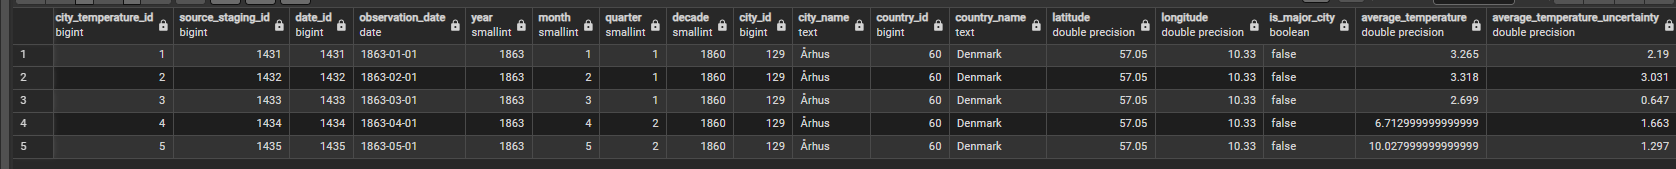

Mẫu kết quả của `vw_city_temperature` cho thấy view đã liên kết thành công dữ liệu fact với các dimension: mỗi bản ghi có khóa truy vết `source_staging_id`, ngày quan sát cùng các thuộc tính năm/tháng/quý/thập niên, và thông tin địa lý gồm thành phố, quốc gia, vĩ độ, kinh độ. Năm dòng đầu là thành phố Århus (Denmark) trong các tháng 01–05/1863, phù hợp với phạm vi thời gian City sau khi cắt ở Mục 8.

Các cột `average_temperature` và `average_temperature_uncertainty` đều xuất hiện đúng trong view; `is_major_city = false` cũng nhất quán với bản ghi City thông thường. Một vài giá trị `DOUBLE PRECISION` hiển thị nhiều chữ số thập phân, chẳng hạn `6.712999999999999`, là đặc điểm biểu diễn số thực dấu chấm động của PostgreSQL, không phải giá trị nhiệt độ bị thay đổi.

Ảnh hiện tại chỉ minh họa dữ liệu mẫu của view City. Bảng đếm ở truy vấn đầu tiên cần được đối chiếu riêng với các số dòng kỳ vọng ở Mục 9 để xác nhận cả năm analytical views không bị mất hoặc nhân bản bản ghi.

## 11. Thực hiện joins và kiểm tra unmatched rows

Các phép join được kiểm tra theo quan hệ dữ liệu:

- Country → Global theo date_id.
- State → Country theo date_id + country_id.
- City → Country theo date_id + country_id.
- Major City → Country theo date_id + country_id.

Unmatched được xem là **expected** khi khóa tương ứng vốn không tồn tại trong nguồn Country/Global. Trạng thái chỉ PASS khi không có row multiplication và không có unexpected unmatched. Truy vấn City có hơn năm triệu dòng nên có thể mất một khoảng thời gian.


### 11.1. Xác định tiêu chí kiểm tra join

Mỗi phép kiểm tra dùng `LEFT JOIN` để bảo toàn toàn bộ dòng của bảng nguồn. Kết quả cần đo: số dòng nguồn, số dòng sau join, số dòng khớp, số dòng không khớp, số dòng không khớp được dự kiến và số dòng không khớp bất thường. Một join chỉ đạt `PASS` khi `row_multiplication = 0` và `unexpected_unmatched = 0`.

### 11.2. Thực hiện bốn phép join và validation

In [ ]:
WITH
global_range AS (
    SELECT
        MIN(observation_date) AS min_date,
        MAX(observation_date) AS max_date
    FROM vw_global_temperature
),
raw_country_keys AS (
    SELECT DISTINCT dt, country
    FROM staging_country
),
country_joined AS (
    SELECT
        c.country_temperature_id AS source_id,
        c.observation_date,
        g.global_temperature_id AS target_id,
        r.min_date,
        r.max_date
    FROM vw_country_temperature AS c
    CROSS JOIN global_range AS r
    LEFT JOIN vw_global_temperature AS g
      ON g.date_id = c.date_id
),
state_joined AS (
    SELECT
        s.state_temperature_id AS source_id,
        c.country_temperature_id AS target_id,
        raw.country AS raw_country_key
    FROM vw_state_temperature AS s
    LEFT JOIN vw_country_temperature AS c
      ON c.date_id = s.date_id
     AND c.country_id = s.country_id
    LEFT JOIN raw_country_keys AS raw
      ON raw.dt = s.observation_date
     AND raw.country = s.country_name
),
city_joined AS (
    SELECT
        ci.city_temperature_id AS source_id,
        c.country_temperature_id AS target_id,
        raw.country AS raw_country_key
    FROM vw_city_temperature AS ci
    LEFT JOIN vw_country_temperature AS c
      ON c.date_id = ci.date_id
     AND c.country_id = ci.country_id
    LEFT JOIN raw_country_keys AS raw
      ON raw.dt = ci.observation_date
     AND raw.country = ci.country_name
),
major_city_joined AS (
    SELECT
        ci.major_city_temperature_id AS source_id,
        c.country_temperature_id AS target_id,
        raw.country AS raw_country_key
    FROM vw_major_city_temperature AS ci
    LEFT JOIN vw_country_temperature AS c
      ON c.date_id = ci.date_id
     AND c.country_id = ci.country_id
    LEFT JOIN raw_country_keys AS raw
      ON raw.dt = ci.observation_date
     AND raw.country = ci.country_name
),
validation AS (
    SELECT
        'country_to_global'::TEXT AS join_name,
        COUNT(*)::BIGINT AS source_rows,
        COUNT(*)::BIGINT AS joined_rows,
        COUNT(target_id)::BIGINT AS matched_rows,
        COUNT(*) FILTER (WHERE target_id IS NULL)::BIGINT AS unmatched_rows,
        COUNT(*) FILTER (
            WHERE target_id IS NULL
              AND observation_date NOT BETWEEN min_date AND max_date
        )::BIGINT AS expected_unmatched,
        COUNT(*) FILTER (
            WHERE target_id IS NULL
              AND observation_date BETWEEN min_date AND max_date
        )::BIGINT AS unexpected_unmatched,
        COUNT(*) - COUNT(DISTINCT source_id) AS row_multiplication
    FROM country_joined

    UNION ALL

    SELECT
        'state_to_country',
        COUNT(*),
        COUNT(*),
        COUNT(target_id),
        COUNT(*) FILTER (WHERE target_id IS NULL),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NULL
        ),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NOT NULL
        ),
        COUNT(*) - COUNT(DISTINCT source_id)
    FROM state_joined

    UNION ALL

    SELECT
        'city_to_country',
        COUNT(*),
        COUNT(*),
        COUNT(target_id),
        COUNT(*) FILTER (WHERE target_id IS NULL),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NULL
        ),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NOT NULL
        ),
        COUNT(*) - COUNT(DISTINCT source_id)
    FROM city_joined

    UNION ALL

    SELECT
        'major_city_to_country',
        COUNT(*),
        COUNT(*),
        COUNT(target_id),
        COUNT(*) FILTER (WHERE target_id IS NULL),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NULL
        ),
        COUNT(*) FILTER (
            WHERE target_id IS NULL AND raw_country_key IS NOT NULL
        ),
        COUNT(*) - COUNT(DISTINCT source_id)
    FROM major_city_joined
)
SELECT
    *,
    ROUND(
        100.0 * matched_rows / NULLIF(source_rows, 0),
        4
    ) AS match_rate_percent,
    CASE
        WHEN row_multiplication = 0
         AND unexpected_unmatched = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM validation
ORDER BY join_name;


Truy vấn thực hiện bốn validation theo từng CTE và trả về một dòng kết quả cho mỗi phép join:

- `country_to_global`: nối Country với Global theo `date_id`. Một dòng Country không có Global chỉ được xem là expected khi ngày đó nằm ngoài dải thời gian Global.
- `state_to_country`: nối State với Country theo `date_id + country_id`. Với State/City/Major City, một unmatched là expected khi cặp ngày–quốc gia vốn không tồn tại trong `staging_country`.
- `city_to_country`: áp dụng cùng điều kiện cho dữ liệu City đã cắt ở Mục 8; đây là phần có quy mô lớn nhất nên thời gian chạy có thể lâu hơn.
- `major_city_to_country`: kiểm tra tập Major City theo cùng khóa ngày–quốc gia.

`raw_country_keys` là tập khóa ngày–quốc gia duy nhất của nguồn Country, dùng để phân biệt unmatched do thiếu dữ liệu nguồn (expected) với lỗi join trong phạm vi dữ liệu hiện có (unexpected). Cột `row_multiplication` phát hiện trường hợp một dòng nguồn ghép với nhiều dòng đích.

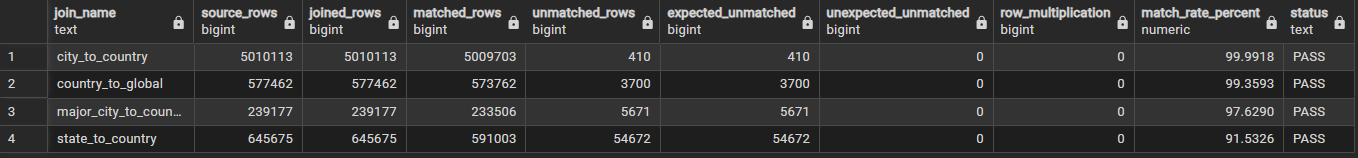

Cả bốn phép join đều đạt `PASS`: số dòng sau join đúng bằng số dòng nguồn và `row_multiplication = 0`, nên không có bản ghi nào bị nhân lên. Đồng thời, `unexpected_unmatched = 0` ở mọi phép join, xác nhận điều kiện khóa `date_id` hoặc `date_id + country_id` hoạt động đúng trong phạm vi dữ liệu nguồn.

Các unmatched đều được phân loại là expected: Country→Global có **3.700/577.462** dòng (match **99,3593%**); State→Country có **54.672/645.675** dòng (match **91,5326%**); City→Country có **410/5.010.113** dòng (match **99,9918%**); và Major City→Country có **5.671/239.177** dòng (match **97,6290%**). Các dòng này xuất hiện khi khóa tương ứng vốn không có trong nguồn Global/Country, không phải do lỗi join.

### 11.3. Minh họa join làm giàu dữ liệu City → Country → Global

In [ ]:
-- Minh họa enrichment City → Country → Global.
SELECT
    ci.observation_date,
    ci.city_name,
    ci.country_name,
    ci.average_temperature AS city_temperature,
    c.average_temperature AS country_temperature,
    g.land_average_temperature AS global_land_temperature
FROM vw_city_temperature AS ci
LEFT JOIN vw_country_temperature AS c
  ON c.date_id = ci.date_id
 AND c.country_id = ci.country_id
LEFT JOIN vw_global_temperature AS g
  ON g.date_id = ci.date_id
ORDER BY ci.city_temperature_id
LIMIT 10;


Truy vấn minh họa bắt đầu từ từng quan sát City, nối sang nhiệt độ quốc gia bằng `date_id + country_id`, rồi nối sang nhiệt độ toàn cầu bằng `date_id`. `LEFT JOIN` được dùng để vẫn hiển thị dòng City nếu Country hoặc Global không có bản ghi tương ứng.

Mẫu 10 dòng giúp đối chiếu trực quan ba cấp nhiệt độ tại cùng thời điểm. Đây chỉ là truy vấn minh họa, không tạo bảng mới và không thay đổi dữ liệu trong database.

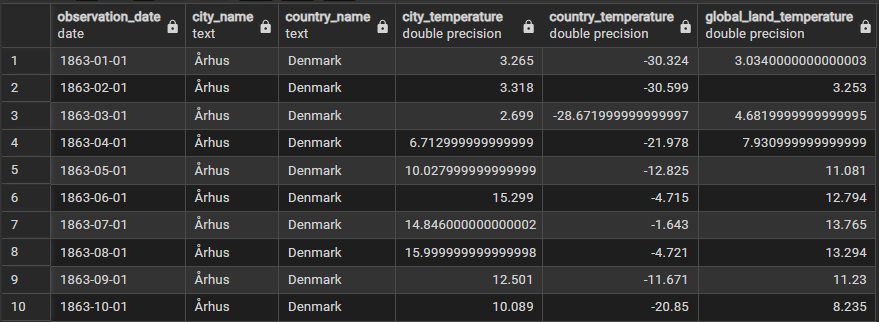

Mẫu 10 dòng cho thấy phép join làm giàu dữ liệu hoạt động đúng: mỗi quan sát của Århus, Denmark từ tháng 01 đến tháng 10/1863 đều có đồng thời `city_temperature`, `country_temperature` và `global_land_temperature`. Không có giá trị `NULL` trong ba cột nhiệt độ của mẫu này.

Nhiệt độ thành phố, quốc gia và toàn cầu có thể khác biệt đáng kể vì chúng đại diện cho các cấp không gian khác nhau; ví dụ tháng 01/1863, Århus là `3.265` trong khi Denmark là `-30.324` và mức toàn cầu là khoảng `3.034`. Đây là kết quả mong đợi của việc đối chiếu giữa các grain, không phải dấu hiệu join sai. Các số có nhiều chữ số thập phân là đặc điểm hiển thị của `DOUBLE PRECISION`.

## 12. Chạy aggregation queries

Materialized views cung cấp dữ liệu tổng hợp theo năm/thập kỷ mà không làm thay đổi monthly views bàn giao cho cleaning. AVG bỏ qua NULL, trong khi các cột observation_months, valid_temperature_months và missing_temperature_months giữ khả năng đánh giá độ phủ dữ liệu.


### 12.1. Tạo các materialized view tổng hợp

Các tổng hợp được tạo từ analytical views ở Mục 10. Chúng được lưu vật lý dưới dạng materialized view để phục vụ phân tích nhanh hơn, nhưng không thay thế hay làm thay đổi dữ liệu monthly gốc.

#### 12.1.1. Tổng hợp nhiệt độ toàn cầu theo năm và thập kỷ

Hai materialized view tổng hợp `vw_global_temperature`: một view theo từng năm và một view theo thập kỷ. Cả hai giữ số tháng quan sát, số tháng hợp lệ và số tháng thiếu để kết quả trung bình có đầy đủ ngữ cảnh.

In [ ]:
CREATE MATERIALIZED VIEW mv_global_temperature_yearly AS
SELECT
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(land_average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE land_average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(land_average_temperature) AS average_land_temperature,
    MIN(land_average_temperature) AS minimum_land_temperature,
    MAX(land_average_temperature) AS maximum_land_temperature,
    AVG(land_average_temperature_uncertainty) AS average_land_uncertainty,
    AVG(land_and_ocean_average_temperature) AS average_land_ocean_temperature,
    AVG(
        land_and_ocean_average_temperature_uncertainty
    ) AS average_land_ocean_uncertainty
FROM vw_global_temperature
GROUP BY year;

CREATE MATERIALIZED VIEW mv_global_temperature_decadal AS
SELECT
    decade,
    MIN(year)::SMALLINT AS first_year,
    MAX(year)::SMALLINT AS last_year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(land_average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE land_average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(land_average_temperature) AS average_land_temperature,
    MIN(land_average_temperature) AS minimum_land_temperature,
    MAX(land_average_temperature) AS maximum_land_temperature,
    AVG(land_average_temperature_uncertainty) AS average_land_uncertainty,
    AVG(land_and_ocean_average_temperature) AS average_land_ocean_temperature,
    AVG(
        land_and_ocean_average_temperature_uncertainty
    ) AS average_land_ocean_uncertainty
FROM vw_global_temperature
GROUP BY decade;

Khối lệnh tạo `mv_global_temperature_yearly` theo grain `year` và `mv_global_temperature_decadal` theo grain `decade`. `MIN(year)` và `MAX(year)` trong view thập kỷ cho biết phạm vi năm thực tế của từng nhóm. `AVG` tự bỏ qua `NULL`, còn các cột đếm vẫn ghi nhận số tháng thiếu.

#### 12.1.2. Tổng hợp nhiệt độ theo quốc gia từng năm

`mv_country_temperature_yearly` nhóm dữ liệu theo `(country_id, year)`, cung cấp nhiệt độ trung bình, thấp nhất, cao nhất và độ bất định trung bình của mỗi quốc gia trong năm.

In [ ]:
CREATE MATERIALIZED VIEW mv_country_temperature_yearly AS
SELECT
    country_id,
    country_name,
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(average_temperature) AS average_temperature,
    MIN(average_temperature) AS minimum_temperature,
    MAX(average_temperature) AS maximum_temperature,
    AVG(average_temperature_uncertainty) AS average_temperature_uncertainty
FROM vw_country_temperature
GROUP BY country_id, country_name, year;

Câu lệnh tạo một dòng cho mỗi cặp quốc gia–năm. `country_id` là khóa phân nhóm chính, còn `country_name` được giữ lại để kết quả dễ đọc. Ba cột đếm cho biết tổng số tháng, số tháng có nhiệt độ và số tháng thiếu.

#### 12.1.3. Tổng hợp nhiệt độ theo bang/tỉnh từng năm

`mv_state_temperature_yearly` dùng grain `(state_id, year)`. Thông tin quốc gia được giữ trong kết quả để phân biệt các bang/tỉnh có thể trùng tên ở những quốc gia khác nhau.

In [ ]:
CREATE MATERIALIZED VIEW mv_state_temperature_yearly AS
SELECT
    state_id,
    state_name,
    country_id,
    country_name,
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(average_temperature) AS average_temperature,
    MIN(average_temperature) AS minimum_temperature,
    MAX(average_temperature) AS maximum_temperature,
    AVG(average_temperature_uncertainty) AS average_temperature_uncertainty
FROM vw_state_temperature
GROUP BY state_id, state_name, country_id, country_name, year;

Dữ liệu được nhóm theo bang/tỉnh, quốc gia và năm. Việc giữ cả `state_id` và `country_id` bảo toàn ngữ cảnh địa lý, trong khi các hàm `AVG`, `MIN`, `MAX` mô tả phân bố nhiệt độ của từng bang/tỉnh theo năm.

#### 12.1.4. Tổng hợp nhiệt độ theo thành phố từng năm

`mv_city_temperature_yearly` tổng hợp tập City đã cắt ở Mục 8 theo `(city_id, year)`, đồng thời giữ tên, quốc gia, tọa độ và cờ `is_major_city` để phục vụ phân tích địa lý.

In [ ]:
CREATE MATERIALIZED VIEW mv_city_temperature_yearly AS
SELECT
    city_id,
    city_name,
    country_id,
    country_name,
    latitude,
    longitude,
    is_major_city,
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(average_temperature) AS average_temperature,
    MIN(average_temperature) AS minimum_temperature,
    MAX(average_temperature) AS maximum_temperature,
    AVG(average_temperature_uncertainty) AS average_temperature_uncertainty
FROM vw_city_temperature
GROUP BY
    city_id,
    city_name,
    country_id,
    country_name,
    latitude,
    longitude,
    is_major_city,
    year;

Mỗi dòng kết quả đại diện cho một thành phố trong một năm. Tọa độ và `is_major_city` được giữ trong `GROUP BY` để materialized view có thể dùng trực tiếp cho phân tích không gian mà không cần join lại dimension.

#### 12.1.5. Tổng hợp nhiệt độ theo thành phố lớn từng năm

`mv_major_city_temperature_yearly` có cùng grain thành phố–năm nhưng chỉ dùng nguồn Major City. View này phù hợp để so sánh xu hướng của nhóm thành phố lớn.

In [ ]:
CREATE MATERIALIZED VIEW mv_major_city_temperature_yearly AS
SELECT
    city_id,
    city_name,
    country_id,
    country_name,
    latitude,
    longitude,
    is_major_city,
    year,
    COUNT(*)::BIGINT AS observation_months,
    COUNT(average_temperature)::BIGINT AS valid_temperature_months,
    COUNT(*) FILTER (
        WHERE average_temperature IS NULL
    )::BIGINT AS missing_temperature_months,
    AVG(average_temperature) AS average_temperature,
    MIN(average_temperature) AS minimum_temperature,
    MAX(average_temperature) AS maximum_temperature,
    AVG(average_temperature_uncertainty) AS average_temperature_uncertainty
FROM vw_major_city_temperature
GROUP BY
    city_id,
    city_name,
    country_id,
    country_name,
    latitude,
    longitude,
    is_major_city,
    year;

Khối lệnh tổng hợp riêng nguồn `vw_major_city_temperature`. Cấu trúc chỉ số giống City để hai tập kết quả có thể được đối chiếu nhất quán theo thành phố, quốc gia, tọa độ và năm.

Mỗi khối dùng transaction `BEGIN`/`COMMIT` và tạo lại đúng materialized view thuộc tiểu mục đó. Nếu một khối phát sinh lỗi, hãy chạy `ROLLBACK;` trong cùng Query Tool trước khi sửa lỗi và chạy lại. Việc tách cell giúp kiểm tra từng cấp dữ liệu độc lập và xác định nhanh bước gặp vấn đề.

### 12.2. Kiểm tra tính đúng đắn của các tổng hợp

In [ ]:
WITH validation AS (
    SELECT
        'mv_global_temperature_yearly'::TEXT AS materialized_view,
        COUNT(*)::BIGINT AS row_count,
        COUNT(*) - COUNT(DISTINCT year) AS duplicate_grain_rows,
        COUNT(*) FILTER (WHERE year IS NULL) AS null_grain_rows,
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months < 0
               OR missing_temperature_months < 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        ) AS invalid_coverage_rows
    FROM mv_global_temperature_yearly

    UNION ALL

    SELECT
        'mv_global_temperature_decadal',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT decade),
        COUNT(*) FILTER (WHERE decade IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_global_temperature_decadal

    UNION ALL

    SELECT
        'mv_country_temperature_yearly',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT (country_id, year)),
        COUNT(*) FILTER (WHERE country_id IS NULL OR year IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_country_temperature_yearly

    UNION ALL

    SELECT
        'mv_state_temperature_yearly',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT (state_id, year)),
        COUNT(*) FILTER (WHERE state_id IS NULL OR year IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_state_temperature_yearly

    UNION ALL

    SELECT
        'mv_city_temperature_yearly',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT (city_id, year)),
        COUNT(*) FILTER (WHERE city_id IS NULL OR year IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_city_temperature_yearly

    UNION ALL

    SELECT
        'mv_major_city_temperature_yearly',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT (city_id, year)),
        COUNT(*) FILTER (WHERE city_id IS NULL OR year IS NULL),
        COUNT(*) FILTER (
            WHERE observation_months <= 0
               OR valid_temperature_months
                  + missing_temperature_months
                  <> observation_months
        )
    FROM mv_major_city_temperature_yearly
)
SELECT
    *,
    CASE
        WHEN row_count > 0
         AND duplicate_grain_rows = 0
         AND null_grain_rows = 0
         AND invalid_coverage_rows = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM validation
ORDER BY materialized_view;


Truy vấn validation kiểm tra từng materialized view có dữ liệu, không có bản ghi trùng grain, không thiếu khóa nhóm và có quan hệ phủ dữ liệu hợp lệ: `valid_temperature_months + missing_temperature_months = observation_months`.

Mỗi materialized view chỉ đạt `PASS` khi tất cả các chỉ số lỗi bằng 0. Nếu xuất hiện `FAIL`, cần kiểm tra lại mệnh đề `GROUP BY`, khóa grain hoặc nguồn dữ liệu đầu vào trước khi dùng kết quả tổng hợp cho báo cáo/phân tích.

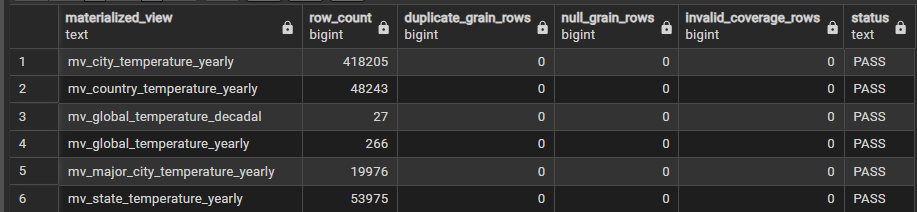

Kết quả validation cho thấy cả **6 materialized view** đều đạt `PASS`. Tất cả đều có `duplicate_grain_rows = 0`, `null_grain_rows = 0` và `invalid_coverage_rows = 0`; vì vậy không có nhóm bị trùng, không thiếu khóa phân nhóm và mọi dòng đều thỏa mãn `valid_temperature_months + missing_temperature_months = observation_months`.

Quy mô kết quả gồm: Global theo năm **266 dòng**, Global theo thập kỷ **27 dòng**, Country theo năm **48.243 dòng**, State theo năm **53.975 dòng**, City theo năm **418.205 dòng** và Major City theo năm **19.976 dòng**. Số dòng City lớn nhất là phù hợp vì mỗi bản ghi đại diện cho một cặp thành phố–năm, trong khi Global chỉ tạo một bản ghi cho mỗi năm hoặc thập kỷ.

Như vậy, các phép aggregation đã bảo toàn đúng grain và thông tin độ phủ dữ liệu. Các materialized view có thể được sử dụng cho phân tích xu hướng theo năm/thập kỷ và làm đầu vào cho các bước báo cáo tiếp theo.

## 13. Tạo indexes và kiểm tra query plan

Indexes được tạo sau bulk load để tránh làm chậm COPY. Primary key và UNIQUE constraints đã tự tạo index nên không lặp lại. Sau khi tạo index, ANALYZE cập nhật thống kê để PostgreSQL planner chọn kế hoạch phù hợp.


### 13.1. Tạo indexes hỗ trợ staging và fact tables

Các index trong phần này phục vụ các khóa thường dùng khi join hoặc truy vấn lịch sử nhiệt độ. Chúng được tạo sau bulk load để không làm chậm quá trình `COPY`.

In [ ]:
CREATE INDEX IF NOT EXISTS idx_staging_country_country_dt
    ON staging_country (country, dt);

CREATE INDEX IF NOT EXISTS idx_fact_country_temperature_country_date
    ON fact_country_temperature (country_id, date_id);

CREATE INDEX IF NOT EXISTS idx_fact_state_temperature_state_date
    ON fact_state_temperature (state_id, date_id);

CREATE INDEX IF NOT EXISTS idx_fact_city_temperature_city_date
    ON fact_city_temperature (city_id, date_id);

CREATE INDEX IF NOT EXISTS idx_fact_major_city_temperature_city_date
    ON fact_major_city_temperature (city_id, date_id);

`idx_staging_country_country_dt` hỗ trợ tra cứu khóa quốc gia–ngày trong bước kiểm tra unmatched. Các index fact đặt thực thể địa lý trước `date_id`, phù hợp với truy vấn lấy toàn bộ lịch sử nhiệt độ của một quốc gia, bang/tỉnh hoặc thành phố rồi sắp xếp theo thời gian. `IF NOT EXISTS` giúp cell có thể chạy lại.

### 13.2. Tạo indexes hỗ trợ dimension tables

In [ ]:
CREATE INDEX IF NOT EXISTS idx_dim_state_country
    ON dim_state (country_id);

CREATE INDEX IF NOT EXISTS idx_dim_city_country_major
    ON dim_city (country_id, is_major_city);

`idx_dim_state_country` tăng tốc truy vấn các bang/tỉnh thuộc một quốc gia. `idx_dim_city_country_major` hỗ trợ lọc thành phố theo quốc gia và tiếp tục phân loại theo `is_major_city`. Primary key và ràng buộc `UNIQUE` đã có index riêng nên không được tạo lặp lại.

### 13.3. Tạo unique indexes cho materialized views

In [ ]:
CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_global_temperature_yearly_year
    ON mv_global_temperature_yearly (year);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_global_temperature_decadal_decade
    ON mv_global_temperature_decadal (decade);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_country_temperature_yearly_grain
    ON mv_country_temperature_yearly (country_id, year);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_state_temperature_yearly_grain
    ON mv_state_temperature_yearly (state_id, year);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_city_temperature_yearly_grain
    ON mv_city_temperature_yearly (city_id, year);

CREATE UNIQUE INDEX IF NOT EXISTS ux_mv_major_city_temperature_yearly_grain
    ON mv_major_city_temperature_yearly (city_id, year);

Sáu unique index phản ánh đúng grain của các materialized view: Global theo năm/thập kỷ và các cấp địa lý theo cặp thực thể–năm. Ngoài việc ngăn grain trùng, unique index còn là điều kiện cần nếu sau này dùng `REFRESH MATERIALIZED VIEW CONCURRENTLY`.

### 13.4. Cập nhật thống kê cho PostgreSQL planner

In [ ]:
ANALYZE staging_country;
ANALYZE fact_country_temperature;
ANALYZE fact_state_temperature;
ANALYZE fact_city_temperature;
ANALYZE fact_major_city_temperature;
ANALYZE dim_state;
ANALYZE dim_city;
ANALYZE mv_global_temperature_yearly;
ANALYZE mv_global_temperature_decadal;
ANALYZE mv_country_temperature_yearly;
ANALYZE mv_state_temperature_yearly;
ANALYZE mv_city_temperature_yearly;
ANALYZE mv_major_city_temperature_yearly;

`ANALYZE` thu thập thống kê về phân bố dữ liệu sau khi tạo và nạp bảng. PostgreSQL planner dùng các thống kê này để ước lượng số dòng và lựa chọn giữa index scan, bitmap scan hoặc sequential scan. Lệnh không thay đổi dữ liệu.

### 13.5. Kiểm tra sự tồn tại của 13 indexes

In [ ]:
WITH expected_indexes(indexname) AS (
    VALUES
        ('idx_staging_country_country_dt'),
        ('idx_fact_country_temperature_country_date'),
        ('idx_fact_state_temperature_state_date'),
        ('idx_fact_city_temperature_city_date'),
        ('idx_fact_major_city_temperature_city_date'),
        ('idx_dim_state_country'),
        ('idx_dim_city_country_major'),
        ('ux_mv_global_temperature_yearly_year'),
        ('ux_mv_global_temperature_decadal_decade'),
        ('ux_mv_country_temperature_yearly_grain'),
        ('ux_mv_state_temperature_yearly_grain'),
        ('ux_mv_city_temperature_yearly_grain'),
        ('ux_mv_major_city_temperature_yearly_grain')
)
SELECT
    e.indexname,
    p.tablename,
    p.indexdef,
    CASE
        WHEN p.indexname IS NOT NULL THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM expected_indexes AS e
LEFT JOIN pg_indexes AS p
  ON p.schemaname = 'public'
 AND p.indexname = e.indexname
ORDER BY e.indexname;

Danh sách kỳ vọng được `LEFT JOIN` với catalog `pg_indexes`. Kết quả phải có đúng 13 dòng và tất cả đều mang trạng thái `PASS`; dòng `FAIL` cho biết index tương ứng chưa tồn tại trong schema `public`.

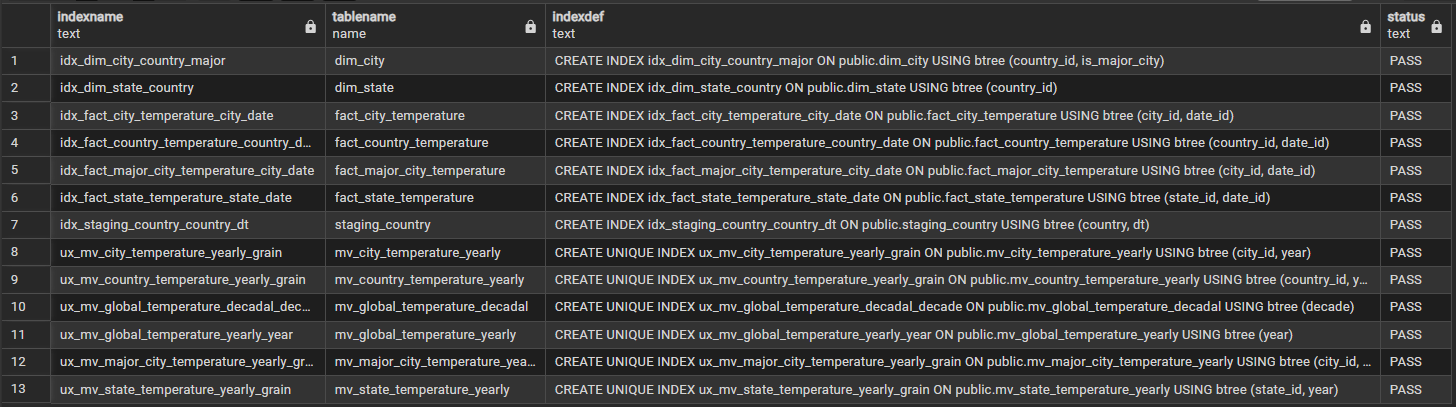

Kết quả trả về đủ **13 index** theo danh sách kỳ vọng và tất cả đều có `status = PASS`. Các index thông thường trên staging, fact và dimension được tạo bằng B-tree với đúng thứ tự cột đã thiết kế; sáu index bắt đầu bằng `ux_` được xác nhận là `UNIQUE INDEX` trên các materialized view.

Như vậy, không có index nào bị thiếu trong schema `public`. Hệ thống đã có các index hỗ trợ khóa join/truy vấn lịch sử và các unique index bảo vệ grain của dữ liệu tổng hợp.

### 13.6. Kiểm tra query plan cho lịch sử nhiệt độ quốc gia

In [ ]:
EXPLAIN (ANALYZE, BUFFERS)
SELECT
    date_id,
    average_temperature
FROM fact_country_temperature
WHERE country_id = (
    SELECT country_id
    FROM fact_country_temperature
    GROUP BY country_id
    ORDER BY COUNT(*) DESC, country_id
    LIMIT 1
)
ORDER BY date_id;

`EXPLAIN (ANALYZE, BUFFERS)` thực thi truy vấn và hiển thị kế hoạch thật. Phần truy vấn ngoài lọc theo `country_id` và sắp xếp theo `date_id`, nên planner có thể sử dụng `idx_fact_country_temperature_country_date`. Cần xem node scan, thời gian thực thi và số buffer thay vì chỉ dựa vào tên index.

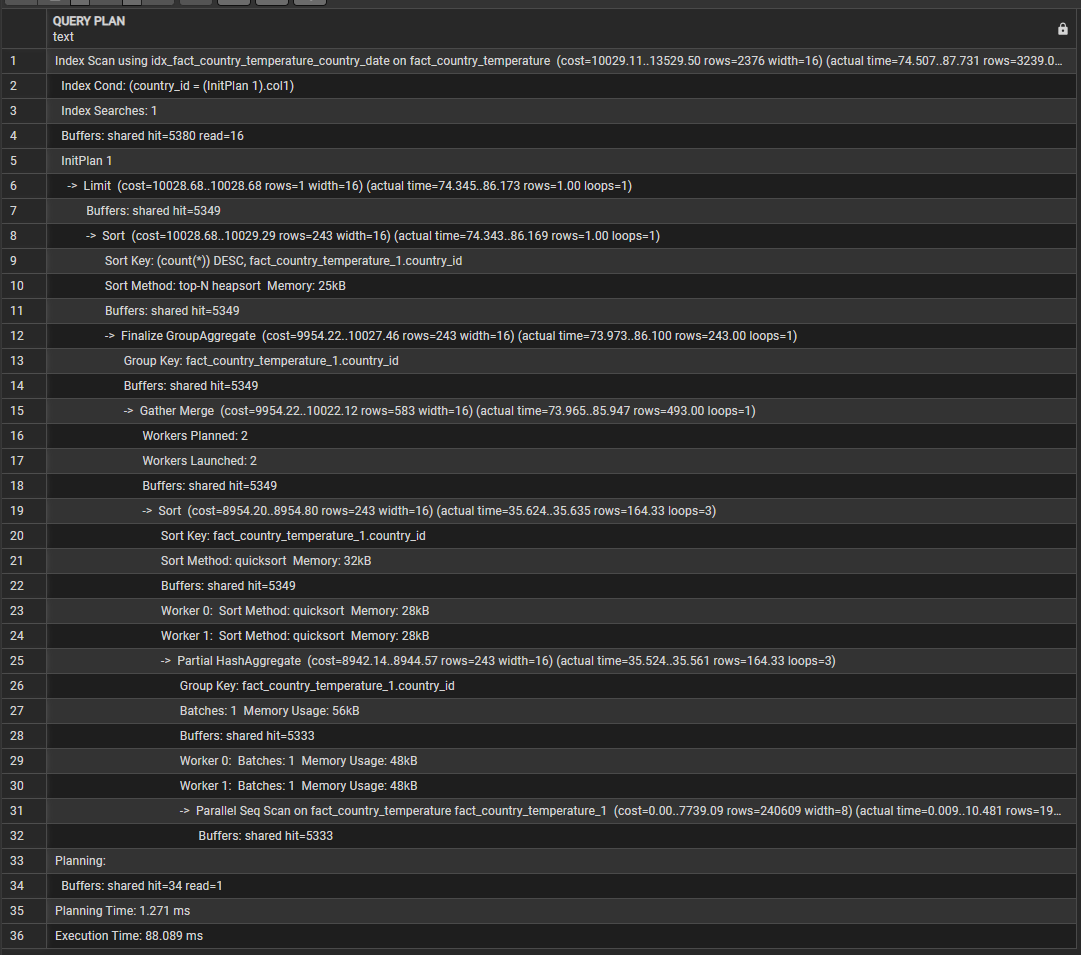

Query plan xác nhận phần truy vấn lịch sử quốc gia sử dụng `Index Scan using idx_fact_country_temperature_country_date`. Điều kiện `country_id` được đưa vào `Index Cond`, chỉ thực hiện **1 index search** và trả về **3.239 dòng** đã có thứ tự theo `date_id`, nên không cần thêm bước sort cho kết quả ngoài.

Subquery tìm quốc gia có nhiều quan sát nhất vẫn dùng `Parallel Seq Scan`, `Partial HashAggregate` và hai worker. Đây là lựa chọn hợp lý vì subquery phải đọc toàn bộ bảng để đếm số dòng của mọi `country_id`; nó không chứng minh index ngoài không hoạt động. Tổng thời gian lập kế hoạch khoảng **1,271 ms** và thời gian thực thi khoảng **88,089 ms**. Kế hoạch này cho thấy composite index đang hỗ trợ đúng phần tra cứu lịch sử quốc gia.

### 13.7. Kiểm tra query plan cho lịch sử nhiệt độ thành phố

In [ ]:
EXPLAIN (ANALYZE, BUFFERS)
SELECT
    date_id,
    average_temperature
FROM fact_city_temperature
WHERE city_id = (
    SELECT city_id
    FROM fact_city_temperature
    GROUP BY city_id
    ORDER BY COUNT(*) DESC, city_id
    LIMIT 1
)
ORDER BY date_id;

Truy vấn chọn thành phố có nhiều quan sát nhất rồi lấy lịch sử theo thời gian. Index `(city_id, date_id)` phù hợp với điều kiện lọc và thứ tự kết quả. Với bảng City lớn, việc thấy `Index Scan` hoặc `Bitmap Index Scan` ở phần truy vấn ngoài là bằng chứng index đang hỗ trợ truy xuất; planner vẫn có thể dùng sequential scan cho subquery thống kê toàn bảng.

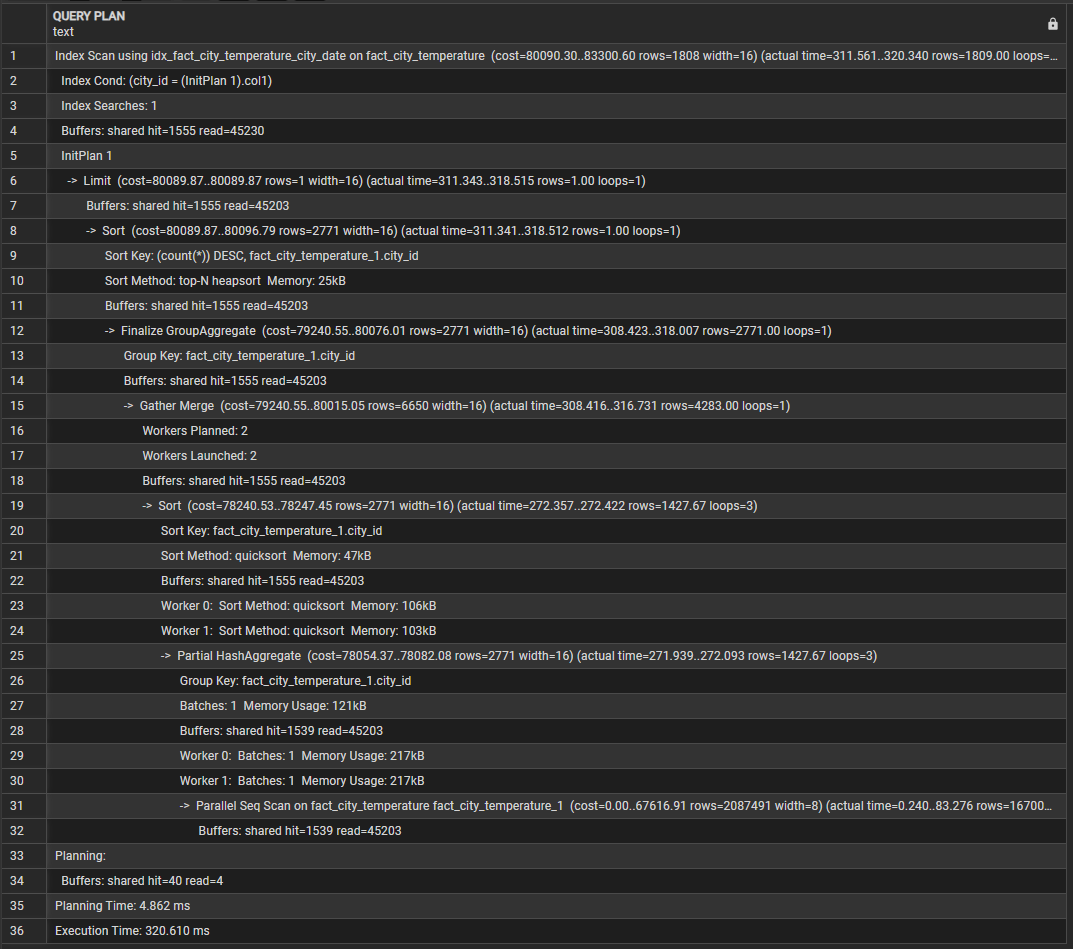

Query plan City sử dụng `Index Scan using idx_fact_city_temperature_city_date` với `Index Cond` trên `city_id`. Phần truy vấn ngoài thực hiện **1 index search** và trả về **1.809 dòng**, tương ứng với số tháng của một thành phố trong giai đoạn City 1863–2013. Điều này xác nhận index `(city_id, date_id)` phù hợp với truy vấn lịch sử thành phố.

Thời gian thực thi toàn truy vấn khoảng **320,610 ms** chủ yếu đến từ subquery tìm thành phố có nhiều quan sát nhất. Subquery phải dùng `Parallel Seq Scan` trên bảng City hơn năm triệu dòng, kết hợp `Partial HashAggregate`, `Gather Merge` và hai worker; số buffer đọc từ đĩa cũng cao hơn truy vấn Country. Vì vậy, chi phí này thuộc bước thống kê toàn bảng, không phải phần `Index Scan` lấy 1.809 dòng lịch sử.

## 14. Final audit và chuyển giao cho Notebook 03

Final audit là bước kiểm tra tổng thể cuối cùng trước khi xác nhận PostgreSQL pipeline đã hoàn thành và bàn giao dữ liệu cho Notebook 03.

Khác với những bước validation trước chỉ kiểm tra từng phần, Final audit kiểm tra toàn bộ pipeline, bao gồm:
- Đủ 5 staging tables.
- Đủ 4 dimension tables.
- Đủ 5 fact tables.
- Đủ 5 monthly analytical views.
- Đủ 6 materialized views.
- Đủ 13 indexes.
- Số dòng của 5 monthly views khớp với số liệu dự kiến.
- Các view vẫn giữ source_staging_id để truy vết về dữ liệu staging.

Final audit kiểm kê database và đối chiếu năm monthly views. Chỉ bàn giao khi kết quả cuối là **POSTGRESQL PIPELINE: READY**.

Notebook 03 sẽ kết nối database đã restore và đọc năm views bằng pd.read_sql(). Cleaning phải giữ source_staging_id hoặc tạo bảng mapping để vẫn truy vết được về staging.

### 14.1. Kiểm kê các database objects của pipeline

In [ ]:
-- Kiểm kê các nhóm object chính.
WITH object_inventory(object_group, expected_count, found_count) AS (
    SELECT
        'staging_tables',
        5::BIGINT,
        COUNT(*)::BIGINT
    FROM information_schema.tables
    WHERE table_schema = 'public'
      AND table_type = 'BASE TABLE'
      AND table_name IN (
          'staging_global',
          'staging_country',
          'staging_state',
          'staging_city',
          'staging_major_city'
      )

    UNION ALL

    SELECT
        'dimension_tables',
        4,
        COUNT(*)
    FROM information_schema.tables
    WHERE table_schema = 'public'
      AND table_type = 'BASE TABLE'
      AND table_name IN (
          'dim_date',
          'dim_country',
          'dim_state',
          'dim_city'
      )

    UNION ALL

    SELECT
        'fact_tables',
        5,
        COUNT(*)
    FROM information_schema.tables
    WHERE table_schema = 'public'
      AND table_type = 'BASE TABLE'
      AND table_name IN (
          'fact_global_temperature',
          'fact_country_temperature',
          'fact_state_temperature',
          'fact_city_temperature',
          'fact_major_city_temperature'
      )

    UNION ALL

    SELECT
        'monthly_views',
        5,
        COUNT(*)
    FROM information_schema.views
    WHERE table_schema = 'public'
      AND table_name IN (
          'vw_global_temperature',
          'vw_country_temperature',
          'vw_state_temperature',
          'vw_city_temperature',
          'vw_major_city_temperature'
      )

    UNION ALL

    SELECT
        'materialized_views',
        6,
        COUNT(*)
    FROM pg_matviews
    WHERE schemaname = 'public'
      AND matviewname IN (
          'mv_global_temperature_yearly',
          'mv_global_temperature_decadal',
          'mv_country_temperature_yearly',
          'mv_state_temperature_yearly',
          'mv_city_temperature_yearly',
          'mv_major_city_temperature_yearly'
      )

    UNION ALL

    SELECT
        'pipeline_indexes',
        13,
        COUNT(*)
    FROM pg_indexes
    WHERE schemaname = 'public'
      AND indexname IN (
          'idx_staging_country_country_dt',
          'idx_fact_country_temperature_country_date',
          'idx_fact_state_temperature_state_date',
          'idx_fact_city_temperature_city_date',
          'idx_fact_major_city_temperature_city_date',
          'idx_dim_state_country',
          'idx_dim_city_country_major',
          'ux_mv_global_temperature_yearly_year',
          'ux_mv_global_temperature_decadal_decade',
          'ux_mv_country_temperature_yearly_grain',
          'ux_mv_state_temperature_yearly_grain',
          'ux_mv_city_temperature_yearly_grain',
          'ux_mv_major_city_temperature_yearly_grain'
      )
)
SELECT
    object_group,
    expected_count,
    found_count,
    CASE
        WHEN expected_count = found_count THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM object_inventory
ORDER BY object_group;

Truy vấn dùng CTE `object_inventory` để kiểm kê sáu nhóm đối tượng trong schema `public`: staging tables, dimension tables, fact tables, monthly views, materialized views và các index do pipeline tạo. Mỗi nhánh lấy số lượng thực tế từ catalog hệ thống phù hợp như `information_schema.tables`, `information_schema.views`, `pg_matviews` hoặc `pg_indexes`.

`expected_count` là số đối tượng thiết kế yêu cầu, còn `found_count` là số đối tượng PostgreSQL thực sự tìm thấy. Một nhóm chỉ đạt `PASS` khi hai giá trị bằng nhau.

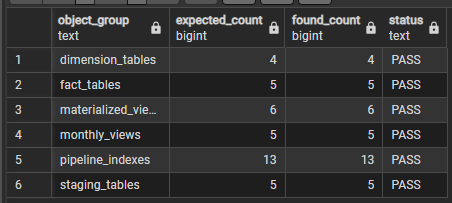

Kết quả kiểm kê cho thấy cả sáu nhóm đều đạt `PASS`: **5 staging tables**, **4 dimension tables**, **5 fact tables**, **5 monthly views**, **6 materialized views** và **13 pipeline indexes** đều được tìm thấy đầy đủ. Không có nhóm nào thiếu hoặc thừa đối tượng so với thiết kế.

Như vậy, cấu trúc vật lý và analytical layer của database đã hoàn chỉnh, đủ điều kiện để tiếp tục kiểm tra data contract bàn giao.

### 14.2. Kiểm tra data contract và trạng thái cuối của pipeline

In [ ]:
-- Data contract bàn giao cho Notebook 03.
WITH handoff(dataset, source_view, expected_rows, actual_rows) AS (
    SELECT
        'global',
        'vw_global_temperature',
        3192::BIGINT,
        COUNT(*)::BIGINT
    FROM vw_global_temperature
    UNION ALL
    SELECT
        'country',
        'vw_country_temperature',
        577462,
        COUNT(*)
    FROM vw_country_temperature
    UNION ALL
    SELECT
        'state',
        'vw_state_temperature',
        645675,
        COUNT(*)
    FROM vw_state_temperature
    UNION ALL
    SELECT
        'city',
        'vw_city_temperature',
        5010113,
        COUNT(*)
    FROM vw_city_temperature
    UNION ALL
    SELECT
        'major_city',
        'vw_major_city_temperature',
        239177,
        COUNT(*)
    FROM vw_major_city_temperature
)
SELECT
    dataset,
    source_view,
    expected_rows,
    actual_rows,
    actual_rows - expected_rows AS difference,
    'source_staging_id' AS lineage_column,
    CASE
        WHEN expected_rows = actual_rows THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM handoff
ORDER BY dataset;

-- Chỉ READY khi mọi monthly view bảo toàn đúng row count.
SELECT
    CASE
        WHEN (SELECT COUNT(*) FROM vw_global_temperature) = 3192
         AND (SELECT COUNT(*) FROM vw_country_temperature) = 577462
         AND (SELECT COUNT(*) FROM vw_state_temperature) = 645675
         AND (SELECT COUNT(*) FROM vw_city_temperature) = 5010113
         AND (SELECT COUNT(*) FROM vw_major_city_temperature) = 239177
        THEN 'POSTGRESQL PIPELINE: READY'
        ELSE 'POSTGRESQL PIPELINE: NOT READY'
    END AS pipeline_status;


Khối SQL thực hiện hai kiểm tra. Truy vấn thứ nhất đối chiếu số dòng thực tế của năm monthly views với số dòng kỳ vọng, tính `difference` và trả `PASS/FAIL` cho từng dataset. Cột `lineage_column` nhắc người nhận tiếp tục bảo toàn `source_staging_id` trong quá trình cleaning.

Truy vấn thứ hai là cổng nghiệm thu cuối: chỉ khi cả năm row count đều đúng, PostgreSQL mới trả `POSTGRESQL PIPELINE: READY`; chỉ cần một điều kiện sai, kết quả sẽ là `NOT READY`.

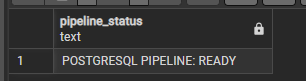

Kết quả cuối là **`POSTGRESQL PIPELINE: READY`**. Điều này xác nhận số dòng của cả năm monthly views đều đúng data contract: Global **3.192**, Country **577.462**, State **645.675**, City **5.010.113** và Major City **239.177**. Database đã đạt điều kiện nghiệm thu để backup và bàn giao cho Notebook 03.

Ảnh hiện tại hiển thị result set thứ hai của khối SQL. Trong pgAdmin, result set thứ nhất có thể được mở ở tab kết quả tương ứng để xem `difference = 0` và `PASS` của từng dataset.

### 14.3. Kiểm tra nguồn dữ liệu bàn giao cho Notebook 03

In [ ]:
-- Các câu lệnh nguồn để người làm Notebook 03 kiểm tra sau restore.
SELECT COUNT(*) AS global_rows
FROM vw_global_temperature;

SELECT COUNT(*) AS country_rows
FROM vw_country_temperature;

SELECT COUNT(*) AS state_rows
FROM vw_state_temperature;

SELECT COUNT(*) AS city_rows
FROM vw_city_temperature;

SELECT COUNT(*) AS major_city_rows
FROM vw_major_city_temperature;

-- Mẫu dữ liệu bàn giao từ các monthly analytical views.
SELECT *
FROM vw_global_temperature
ORDER BY global_temperature_id
LIMIT 10;

SELECT *
FROM vw_country_temperature
ORDER BY country_temperature_id
LIMIT 10;

SELECT *
FROM vw_state_temperature
ORDER BY state_temperature_id
LIMIT 10;

SELECT *
FROM vw_city_temperature
ORDER BY city_temperature_id
LIMIT 10;

SELECT *
FROM vw_major_city_temperature
ORDER BY major_city_temperature_id
LIMIT 10;


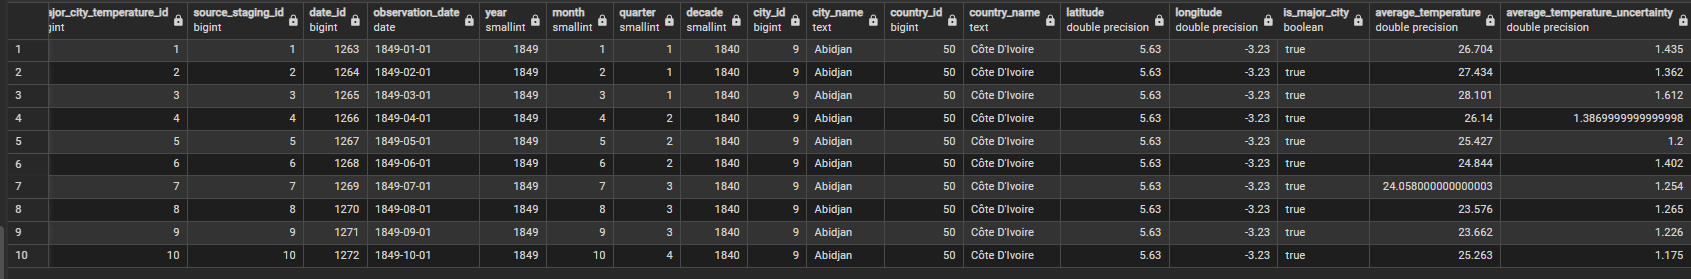

Năm truy vấn `COUNT(*)` giúp người thực hiện Notebook 03 xác nhận row count sau khi restore database. Năm truy vấn tiếp theo lấy 10 dòng mẫu từ từng monthly view để kiểm tra cấu trúc cột, khả năng đọc dữ liệu và khóa `source_staging_id`; tất cả đều chỉ đọc và không làm thay đổi database.

Ảnh hiển thị 10 dòng đầu của `vw_major_city_temperature` cho Abidjan, Côte D'Ivoire trong các tháng 01–10/1849. View có đầy đủ khóa fact, `source_staging_id`, `date_id`, thuộc tính thời gian, tên và tọa độ thành phố, `is_major_city = true`, nhiệt độ trung bình và độ bất định. Điều này xác nhận nguồn Major City có cấu trúc phù hợp để Notebook 03 sử dụng và vẫn truy vết được về staging.

Do ảnh là result set cuối cùng, các kết quả đếm và bốn mẫu view còn lại cần được xem ở những tab kết quả trước trong pgAdmin.

### Backup và restore bằng pgAdmin 4

Sau khi final audit trả **READY**:

1. Trong pgAdmin, nhấp phải **climate_db → Backup…**.
2. Chọn **Format = Plain**, Encoding UTF8 và lấy đủ Pre-data, Data, Post-data.
3. Không lưu Owner, Privileges và Tablespaces để giảm xung đột trên máy thành viên khác.
4. Người làm Notebook 03 tạo database rỗng trên máy họ, nhấp phải database → **Restore…**, chọn **Format = Plain** và file SQL đã nhận.
5. Sau restore, chạy code cell kiểm tra nguồn Notebook 03 ở trên.

### Kết luận

Notebook 02 hoàn thành khi:

- 5 CSV được COPY vào staging với row count đúng.
- Dimensions và facts bảo toàn source lineage.
- 5 monthly views tồn tại và đúng grain.
- 4 join validations không row multiplication hoặc unexpected unmatched.
- 6 materialized views và 13 indexes hợp lệ.
- Final audit trả **POSTGRESQL PIPELINE: READY**.
